## summary

Purpose of this notebook is to see if we can break down the surface contributions in heat and salt to obtain separated terms, and achieve this in the context of KPP in the budget.

Let's load just the terms for creating termsT3D and termsS3D for the surface budget (can copy from the function here).

In [32]:
# auto-reload edited modules
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, "/home/mmurakami/crios_backups/an_helper_functions")

# run the script into the curre nt kernel (vars/functions become available)
%run -i "/home/mmurakami/crios_backups/an_helper_functions/prep_grid_aste_90.py"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
(450, 90)
RAC2d (40500,)
(100,)


In [33]:
import numpy as np
import sys
sys.path.append("/home/mmurakami/MITgcm/MITgcm_c68r/MITgcm-checkpoint68r/utils/python/MITgcmutils/MITgcmutils/") # go to parent dir
from mds import *
import os
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
sys.path.append("/home/mmurakami/crios_backups/an_helper_functions")
from read_binary import *
from calc_UV_conv_1face import calc_UV_conv_1face
from calc_mskmean_T_mod import calc_mskmean_T_mod
from mk3D_mod import mk3D_mod
from aste_helper_funcs import *
from timing_functions import *           # ts2dte, get_fnames, etc.
from binning import *

In [34]:
dirroot = "/scratch3/atnguyen/aste_90x150x60/"
dirgrid = dirroot + "GRID_real8/"
dirgridnb = dirroot + "GRID_noblank/"
runstr= "run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/"
layers_path = dirroot + runstr
extL = "LAYERS"
dirmask = dirroot + "run_template/input_maskTransport/"
dirbudg = layers_path + "diags/BUDG/"
dirdiags = dirbudg
dirstate = layers_path + "diags/STATE/"
dirlayers = layers_path + "diags/LAYERS/"
dirtrsp = layers_path + "diags/TRSP/"

In [35]:
# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)

ind2d = ind.reshape(ny,nx)

In [36]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000003","0000000004"])
t2 = int(tsstr[1]) # for the offline version

In [37]:
# load the mask in 1D to get the points from offline

# try to use rdmds
fileprefix = "/scratch3/atnguyen/aste_90x150x60/"
extBasin='run_template/input_maskTransport/'
filename = fileprefix + extBasin + "GATE_transports_v2_mskBasin.bin"
ind = np.fromfile(filename, dtype=np.int32)  # auto-reads .meta for shape/dtype/order
orig_shape = (ind.shape)
ind2d = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind2d == 57408.0] = 1
# make this smaller
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan
ind = ind.reshape(ny,nx)
mymsk = np.full((ny,nx),np.nan)
mymsk[ind == 57408.0] = 1
mymsk[:,27:50] = np.nan
mymsk[:160,12:30] = np.nan
mymsk[160:163,15:30] = np.nan

# load the indices for layers
mymsk_1d = mymsk.reshape(orig_shape, order='C')
mymsk_1dtile = np.tile(mymsk_1d[np.newaxis,:],(nT-1,1))
# mymsk3d.shape
# hf2dtile.shape
iwet_mine = np.where(~np.isnan(mymsk_1d))
iwet_mine[0].shape
iwet_mine = iwet_mine[0]   # this is already the 1D array of wetpoints to use, we can add these below by indexing
mymsk3d = np.tile(mymsk[np.newaxis,:,:],(nz,1,1))

In [38]:
landmsk = np.zeros((ny,nx))
landmsk[np.isnan(mygrid['hFacC'][0])] = 1
land_dataf3 = get_aste_faces(landmsk,nfx,nfy).f3[0]
land_dataf3[land_dataf3==0]  = np.nan
landmsk[landmsk==0]= np.nan

## Breakdown of the surface heat budget

In [39]:
# we need TFLUX from before
# to get the surface term, we need J/s and convert to degC.m^3/s
file_name = 'budg2d_zflux_set1'
meta_budg2d_zflux_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set1["fldList"])
varnames = np.array(["TFLUX","oceQsw","SItflux"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
TFLUX,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
oceQsw,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
SItflux,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
TFLUX = TFLUX.reshape(ny,nx)
oceQsw = oceQsw.reshape(ny,nx)
SItflux = SItflux.reshape(ny,nx)  # + increase T

# we need to create zconv_top and swtop
dd = mygrid['RF'][:-1]
swfrac = 0.62*np.exp(dd/0.6)+(1-0.62)*np.exp(dd/20)
swfrac[dd < -200] = 0
swtop=mk3D_mod(swfrac,np.zeros((nz,ny,nx)))*mk3D_mod(RAC*oceQsw,np.zeros((nz,ny,nx)))   # J/s

# zconvtop_heat is here
zconv_top_heat = TFLUX * RAC     # W/m^2 * m^2 = J/s

In [40]:
oceQsw.shape

(450, 90)

In [41]:
# note: the following works provided that the first 3 terms are definitely there
file_name = "budg2d_zflux_set2"
meta_budg2d_zflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set2["fldList"])
# print(fldlist)
varnames = np.array(["oceQnet","WTHMASS","SIaaflux"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
oceQnet,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
WTHMASS,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
SIaaflux,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
oceQnet = oceQnet.reshape(ny,nx)
WTHMASS = WTHMASS.reshape(ny,nx)
SIaaflux = SIaaflux.reshape(ny,nx)

# note: will not work if these are defined, fix for future steps
varnames = np.array(["TRELAX","SIabflux","SIacflux","SIeprflx","SIfldflx"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    if len(irec[0]) > 0:
        recs = np.append(recs, irec[0][0])

# if len(recs) == 0:
TRELAX = np.zeros((ny,nx))
SIabflux = np.zeros((ny, nx))
SIacflux = np.zeros((ny, nx))
SIeprflx = np.zeros((ny, nx))
SIfldflx = np.zeros((ny, nx))

In [42]:
# read theta and salt averages from the t2 timestep (average)
file_name = "state_3d_set1"
meta_state_3d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_3d_set1["fldList"])
varnames = np.array(["THETA","SALT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
THETA,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[0])
SALT,its,meta = rdmds(os.path.join(dirstate, file_name),t2,returnmeta=True,rec=recs[1])

THETA = THETA.reshape(nz,ny,nx)
SALT = SALT.reshape(nz,ny,nx)

In [44]:
# ------------------------------------------------------------
# Total surface forcing pieces in J/s
# ------------------------------------------------------------
Q_total = TFLUX * RAC
Q_sw_top = oceQsw * RAC
Q_nonSW_top = (TFLUX - oceQsw) * RAC

swtop = mk3D_mod(swfrac, np.zeros((nz, ny, nx))) * \
        mk3D_mod(RAC * oceQsw, np.zeros((nz, ny, nx)))

# ------------------------------------------------------------
# Total surface contribution
# ------------------------------------------------------------
Ft_surf = surface_contrib_JT(
    Q_total,
    swtop,
    myparms["rcp"]
)

# ------------------------------------------------------------
# Piece 1: non-shortwave top boundary flux only
# ------------------------------------------------------------
Ft_nonSW_top = surface_contrib_JT(
    Q_nonSW_top,
    np.zeros((nz, ny, nx)),
    myparms["rcp"]
)

# ------------------------------------------------------------
# Piece 2: shortwave entering at the top boundary only
# ------------------------------------------------------------
Ft_Qsw_top = surface_contrib_JT(
    Q_sw_top,
    np.zeros((nz, ny, nx)),
    myparms["rcp"]
)

# ------------------------------------------------------------
# Piece 3: shortwave redistribution by penetration
# ------------------------------------------------------------
Ft_sw_redistrib = surface_contrib_JT(
    np.zeros((ny, nx)),
    swtop,
    myparms["rcp"]
)

# ------------------------------------------------------------
# Closure check
# ------------------------------------------------------------
Ft_recon = Ft_nonSW_top + Ft_Qsw_top + Ft_sw_redistrib
print("max abs closure error:", np.nanmax(np.abs(Ft_surf - Ft_recon)))

max abs closure error: 1.1641532182693481e-10


In [45]:
############################################################
# surface heat diagnostics in J/s
Q_total      = TFLUX * RAC                  # total surface heat input
Qsw_top      = oceQsw * RAC                 # shortwave entering through surface
QnonSW_top   = (TFLUX - oceQsw) * RAC       # non-shortwave surface heat input

swtop = (
    mk3D_mod(swfrac, np.zeros((nz, ny, nx))) *
    mk3D_mod(RAC * oceQsw, np.zeros((nz, ny, nx)))
)

############################################################
def surface_contrib_JT(zconv_top_heat, swtop, rcp, fill_last=0.0):
    """
    zconv_top_heat: (ny, nx)     surface convergence term in J/s
    swtop:          (nz, ny, nx) penetrating downward flux profile in J/s
    returns:
      JsurfT:       (nz, ny, nx) in degC.m^3/s
    """
    nz_, ny_, nx_ = swtop.shape
    eT = zconv_top_heat.reshape(1, ny_, nx_)
    J = np.empty_like(swtop, dtype=float)

    J[0] = (eT[0] - swtop[1]) / rcp
    J[1:nz_-1] = -(swtop[2:nz_] - swtop[1:nz_-1]) / rcp
    J[-1] = fill_last

    return J

############################################################
# original total surface contribution
Ft_surf = surface_contrib_JT(
    Q_total,
    swtop,
    myparms['rcp']
)

############################################################
# split into physically interpretable pieces

# 1) non-shortwave top-boundary contribution
Ft_nonSW_top = surface_contrib_JT(
    QnonSW_top,
    np.zeros((nz, ny, nx)),
    myparms['rcp']
)

# 2) shortwave top-boundary entry only
Ft_Qsw_top = surface_contrib_JT(
    Qsw_top,
    np.zeros((nz, ny, nx)),
    myparms['rcp']
)

# 3) shortwave redistribution by penetration
Ft_swredistrib = surface_contrib_JT(
    np.zeros((ny, nx)),
    swtop,
    myparms['rcp']
)

# optional combined shortwave term
Ft_shortwave = Ft_Qsw_top + Ft_swredistrib

############################################################
# closure checks
print("max abs error, 3-term closure:",
      np.nanmax(np.abs(Ft_surf - (Ft_nonSW_top + Ft_Qsw_top + Ft_swredistrib))))

print("max abs error, 2-term closure:",
      np.nanmax(np.abs(Ft_surf - (Ft_nonSW_top + Ft_shortwave))))

############################################################
# mapping return: surface terms
termsT3D = {}
termsT3D["TFLUX"]         = Ft_surf
termsT3D["nonSW_top"]     = Ft_nonSW_top
termsT3D["Qsw_top"]       = Ft_Qsw_top
termsT3D["swredistrib"]   = Ft_swredistrib
termsT3D["shortwave"]     = Ft_shortwave

############################################################
# binning: surface terms
term_names = [
    "TFLUX",
    "nonSW_top",
    "Qsw_top",
    "swredistrib",
    "shortwave",
]

term_fields = {
    "TFLUX":       Ft_surf,
    "nonSW_top":   Ft_nonSW_top,
    "Qsw_top":     Ft_Qsw_top,
    "swredistrib": Ft_swredistrib,
    "shortwave":   Ft_shortwave,
}

nterms = len(term_names)
dF_Tnew = np.zeros((nterms, nT - 1))
G_T_offline_new = np.zeros((nterms, nT - 1))
Lijnew = np.zeros((1, nT - 1), dtype=int)

T_flat = np.ravel(THETA * mymsk3d, order='F')
term_flats = {
    name: np.ravel(field * mymsk3d, order='F')
    for name, field in term_fields.items()
}

for i in range(nT - 1):
    ij = np.where((T_flat >= binmidT[i]) & (T_flat < binmidT[i + 1]))[0]
    Lijnew[0, i] = len(ij)

    if len(ij) > 0:
        for it, name in enumerate(term_names):
            dF_Tnew[it, i] = np.nansum(term_flats[name][ij])

G_T_offline_new = dF_Tnew / binwidthT1[None, :]

dF_T_dict = {name: dF_Tnew[it] for it, name in enumerate(term_names)}
G_T_dict  = {name: G_T_offline_new[it] for it, name in enumerate(term_names)}

max abs error, 3-term closure: 1.1641532182693481e-10
max abs error, 2-term closure: 1.1641532182693481e-10


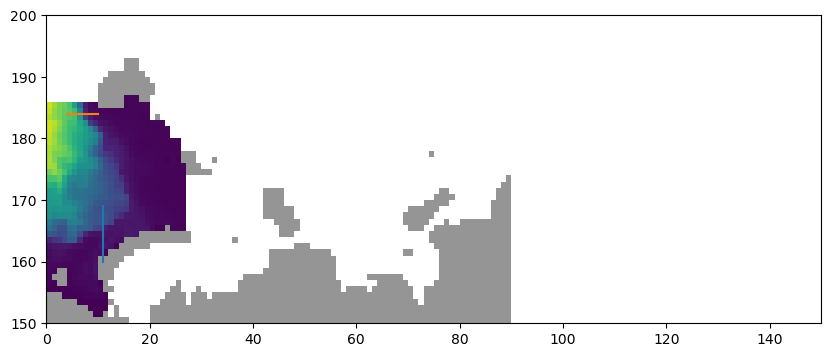

In [46]:
plt.pcolormesh(THETA[0] * mymsk)
plt.pcolormesh(landmsk,cmap="Greys",vmin=0,vmax=2)
x_section = np.arange(160,170,1)
y_section = np.full_like(x_section,11)
plt.plot(y_section,x_section)

y_section2 = np.arange(4,11,1)
x_section2 = np.full_like(y_section2,184)
plt.plot(y_section2,x_section2)
plt.xlim(0,150)
plt.ylim(150,200)

section_mask = np.full((ny,nx),np.nan)
section_mask[x_section2,y_section2] = 1
section_mask[x_section,y_section] = 1

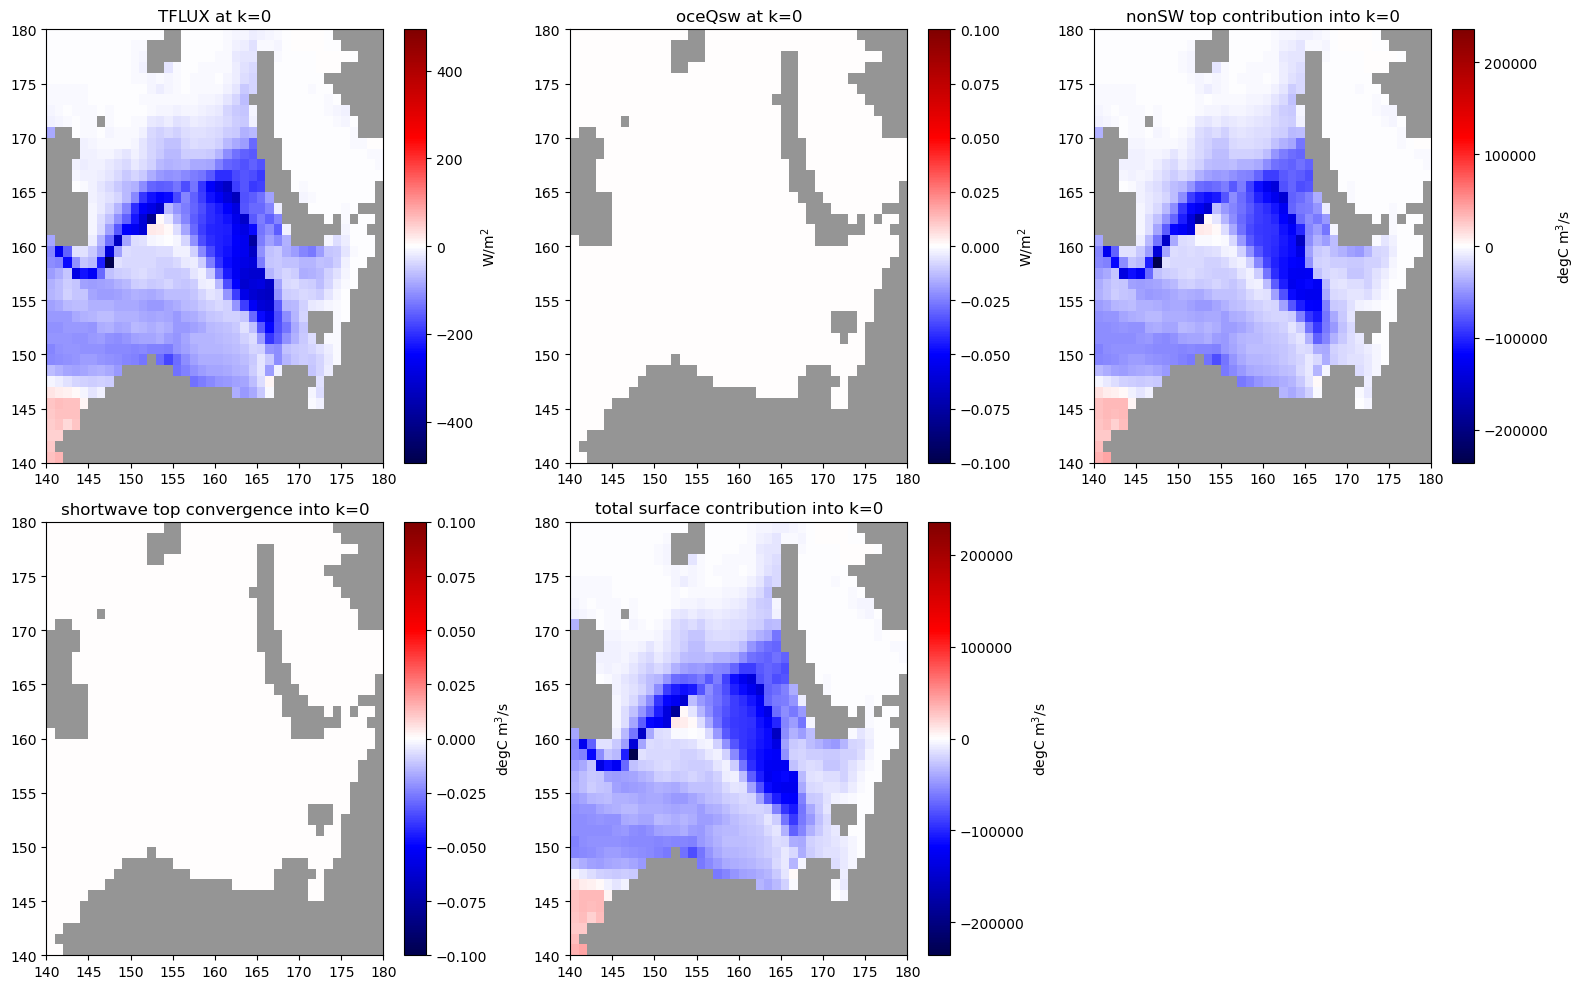

In [57]:
# plot each of the terms here and the original flux

fig = plt.figure(figsize=(16, 10))

# -------------------------------
# 1) total TFLUX
# -------------------------------
ax = plt.subplot(231)
vlev = np.nanmax(np.abs(TFLUX * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(TFLUX, nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="W/m$^2$")
ax.set_title("TFLUX at k=0")

# -------------------------------
# 2) surface shortwave input
# -------------------------------
ax = plt.subplot(232)
vlev = np.nanmax(np.abs(oceQsw * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(oceQsw, nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="W/m$^2$")
ax.set_title("oceQsw at k=0")

# -------------------------------
# 3) non-shortwave top contribution
# -------------------------------
ax = plt.subplot(233)
vlev = np.nanmax(np.abs(Ft_nonSW_top[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Ft_nonSW_top[0], nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="degC m$^3$/s")
ax.set_title("nonSW top contribution into k=0")

# -------------------------------
# 4) shortwave top-entry contribution
# -------------------------------
ax = plt.subplot(234)
vlev = np.nanmax(np.abs(Ft_Qsw_top[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Ft_Qsw_top[0], nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="degC m$^3$/s")
ax.set_title("shortwave top convergence into k=0")

# -------------------------------
# 6) total reconstructed surface contribution
# -------------------------------
ax = plt.subplot(235)
vlev = np.nanmax(np.abs(Ft_surf[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Ft_surf[0], nfx, nfy)[0],
    cmap='seismic',
    vmin=-vlev,
    vmax=vlev
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="degC m$^3$/s")
ax.set_title("total surface contribution into k=0")

plt.tight_layout()
plt.show()

In [49]:
from matplotlib.gridspec import GridSpec


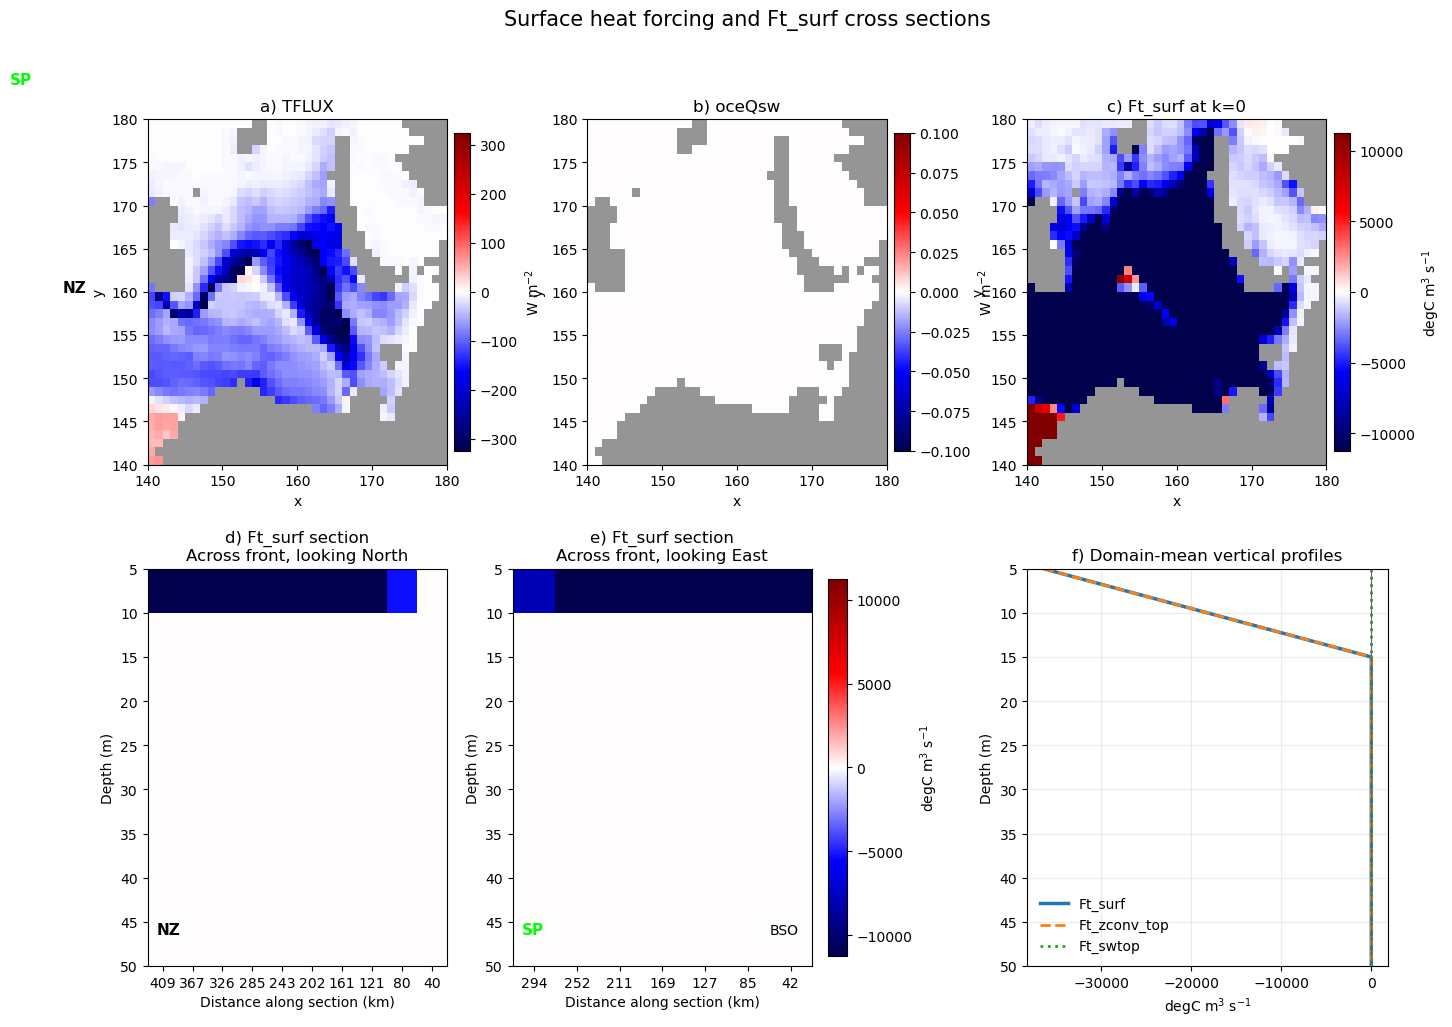

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.gridspec import GridSpec

# --------------------------------------------------
# helper: depth at cell centers
# --------------------------------------------------
z = np.cumsum(mygrid["DRF"].squeeze())
z1 = np.concatenate(([0], z))
z = 0.5 * (z1[1:] + z1[:-1])

# --------------------------------------------------
# robust color limits for transformed terms
# use percentile instead of absolute max to avoid one-cell blowups
# --------------------------------------------------
ft_all = np.concatenate([
    Ft_surf[np.isfinite(Ft_surf * mymsk3d)],
    Ft_zconv_top[np.isfinite(Ft_zconv_top * mymsk3d)],
    Ft_swtop[np.isfinite(Ft_swtop * mymsk3d)],
])

ft_vlev = np.nanpercentile(np.abs(ft_all), 99)
ft_norm = TwoSlopeNorm(vmin=-ft_vlev, vcenter=0.0, vmax=ft_vlev)

# separate scales for raw surface fluxes
tflux_vlev = np.nanpercentile(np.abs(TFLUX * mymsk), 99)
qsw_vlev   = np.nanpercentile(np.abs(oceQsw * mymsk), 99)

# --------------------------------------------------
# section metadata
# --------------------------------------------------
sections = [
    (x_section,  y_section,  "Across front, looking North", "NZ", "k"),
    (x_section2, y_section2, "Across front, looking East",  "SP", "lime"),
]

# --------------------------------------------------
# figure layout
# --------------------------------------------------
fig = plt.figure(figsize=(16, 11))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1, 1.15], hspace=0.28, wspace=0.22)

# ==================================================
# TOP ROW
# ==================================================

# ---------------------------
# 1) TFLUX
# ---------------------------
ax1 = fig.add_subplot(gs[0, 0])
pcm1 = ax1.pcolormesh(
    get_aste_tracer(TFLUX, nfx, nfy)[0],
    cmap="seismic",
    vmin=-tflux_vlev,
    vmax=tflux_vlev,
    shading="auto",
)
ax1.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2,
    shading="auto",
)
ax1.set_xlim(140, 180)
ax1.set_ylim(140, 180)
ax1.set_title("a) TFLUX")
ax1.set_xlabel("x")
ax1.set_ylabel("y")

# ---------------------------
# 2) oceQsw
# ---------------------------
ax2 = fig.add_subplot(gs[0, 1])
pcm2 = ax2.pcolormesh(
    get_aste_tracer(oceQsw, nfx, nfy)[0],
    cmap="seismic",
    vmin=-qsw_vlev,
    vmax=qsw_vlev,
    shading="auto",
)
ax2.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2,
    shading="auto",
)
ax2.set_xlim(140, 180)
ax2.set_ylim(140, 180)
ax2.set_title("b) oceQsw")
ax2.set_xlabel("x")
ax2.set_ylabel("y")

# ---------------------------
# 3) Ft_surf at surface
# ---------------------------
ax3 = fig.add_subplot(gs[0, 2])
pcm3 = ax3.pcolormesh(
    get_aste_tracer(Ft_surf[0], nfx, nfy)[0],
    cmap="seismic",
    norm=ft_norm,
    shading="auto",
)
ax3.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2,
    shading="auto",
)

for xs, ys, _, label, color in sections:
    ax3.plot(ys, xs, color=color, linewidth=2.5)
    ax3.text(ys[0], xs[0], label, color=color, fontsize=11, weight="bold")

ax3.set_xlim(140, 180)
ax3.set_ylim(140, 180)
ax3.set_title("c) Ft_surf at k=0")
ax3.set_xlabel("x")
ax3.set_ylabel("y")

# top-row colorbars
cbar1 = fig.colorbar(pcm1, ax=[ax1], shrink=0.92, pad=0.02)
cbar1.set_label("W m$^{-2}$")

cbar2 = fig.colorbar(pcm2, ax=[ax2], shrink=0.92, pad=0.02)
cbar2.set_label("W m$^{-2}$")

cbar3 = fig.colorbar(pcm3, ax=[ax3], shrink=0.92, pad=0.02)
cbar3.set_label("degC m$^3$ s$^{-1}$")

# ==================================================
# BOTTOM ROW: sections + profiles
# ==================================================

section_axes = []
section_pcms = []

for isec, (xs, ys, row_title, corner_label, color) in enumerate(sections):
    ax = fig.add_subplot(gs[1, isec])
    section_axes.append(ax)

    # field along section
    ft_sec = Ft_surf[:, xs, ys].copy()

    # land mask: safer than np.isnan
    land_hfc = mygrid["hFacC"][:, xs, ys]
    land_sec = np.full_like(land_hfc, np.nan, dtype=float)
    land_sec[land_hfc == 0] = 1

    # distance along section
    # keep your original DYG choice for consistency
    yc_sec = mygrid["DYG"][xs, ys]
    dist_km = np.cumsum(yc_sec) / 1000.0
    dist_km = np.round(dist_km)
    sec_idx = np.arange(len(yc_sec))

    pcm = ax.pcolormesh(
        sec_idx,
        z,
        ft_sec,
        shading="auto",
        cmap="seismic",
        norm=ft_norm,
    )
    section_pcms.append(pcm)

    ax.pcolormesh(
        sec_idx,
        z,
        land_sec,
        cmap="Greys",
        vmin=0,
        vmax=2,
        shading="auto",
    )

    tick_step = max(1, len(sec_idx) // 6)
    tick_idx = sec_idx[::tick_step]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(dist_km.astype(int)[::tick_step])

    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set_ylim(50, 5)

    ax.text(
        0.03, 0.08, corner_label,
        transform=ax.transAxes,
        fontsize=11,
        weight="bold",
        color=color,
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
    )

    if isec == 1:
        ax.text(
            0.86, 0.08, "BSO",
            transform=ax.transAxes,
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="none")
        )

    ax.set_title(f"{chr(100+isec)}) Ft_surf section\n{row_title}")
    ax.set_xlabel("Distance along section (km)")
    ax.set_ylabel("Depth (m)")

# shared section colorbar
cbar_sec = fig.colorbar(section_pcms[0], ax=section_axes, shrink=0.95, pad=0.02)
cbar_sec.set_label("degC m$^3$ s$^{-1}$")

# ---------------------------
# vertical profiles
# ---------------------------
ax6 = fig.add_subplot(gs[1, 2])

ft_surf_prof  = np.nanmean(Ft_surf      * mymsk3d, axis=(1, 2))
ft_zconv_prof = np.nanmean(Ft_zconv_top * mymsk3d, axis=(1, 2))
ft_swtop_prof = np.nanmean(Ft_swtop     * mymsk3d, axis=(1, 2))

ax6.plot(ft_surf_prof,  z, label="Ft_surf",      linewidth=2.5)
ax6.plot(ft_zconv_prof, z, label="Ft_zconv_top", linewidth=2.0, linestyle="--")
ax6.plot(ft_swtop_prof, z, label="Ft_swtop",     linewidth=2.0, linestyle=":")

ax6.axvline(0, color="0.4", linewidth=0.8)
ax6.invert_yaxis()
ax6.set_ylim(50, 5)
ax6.grid(alpha=0.25)
ax6.set_xlabel("degC m$^3$ s$^{-1}$")
ax6.set_ylabel("Depth (m)")
ax6.set_title("f) Domain-mean vertical profiles")
ax6.legend(frameon=False, loc="best")

fig.suptitle("Surface heat forcing and Ft_surf cross sections", fontsize=15, y=0.98)
plt.show()

In [17]:
z = np.cumsum(mygrid["DRF"].squeeze())
z1 = np.array([0])
z1 = np.append(z1,z)
z = (z1[1:] + z1[:-1]) /2  # cell centering
z

array([5.000000e+00, 1.500000e+01, 2.500000e+01, 3.500000e+01,
       4.500000e+01, 5.500000e+01, 6.500000e+01, 7.500500e+01,
       8.502500e+01, 9.509500e+01, 1.053100e+02, 1.158700e+02,
       1.271500e+02, 1.397400e+02, 1.544700e+02, 1.724000e+02,
       1.947350e+02, 2.227100e+02, 2.574700e+02, 2.999300e+02,
       3.506800e+02, 4.099300e+02, 4.774700e+02, 5.527100e+02,
       6.347350e+02, 7.224000e+02, 8.144700e+02, 9.097400e+02,
       1.007155e+03, 1.105905e+03, 1.205535e+03, 1.306205e+03,
       1.409150e+03, 1.517095e+03, 1.634175e+03, 1.765135e+03,
       1.914150e+03, 2.084035e+03, 2.276225e+03, 2.491250e+03,
       2.729250e+03, 2.990250e+03, 3.274250e+03, 3.581250e+03,
       3.911250e+03, 4.264250e+03, 4.640250e+03, 5.039250e+03,
       5.461250e+03, 5.906250e+03])

In [18]:
# add the original breakdown

dt = 1800 # standard for miniaste here for one time step
from create_aste90_layers import create_layers_totalTHETA,create_layers_totalSALT

MsumT,termsT3Dorig = create_layers_totalTHETA(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=True,debug=False)
MsumS,termsS3Dorig = create_layers_totalSALT(tsstr,mygrid,myparms,dirdiags,dirstate,layers_path,mymsk,nz,ny,nx,nfx,nfy,dt,boundsT,boundsS,mapping=True,debug=False)


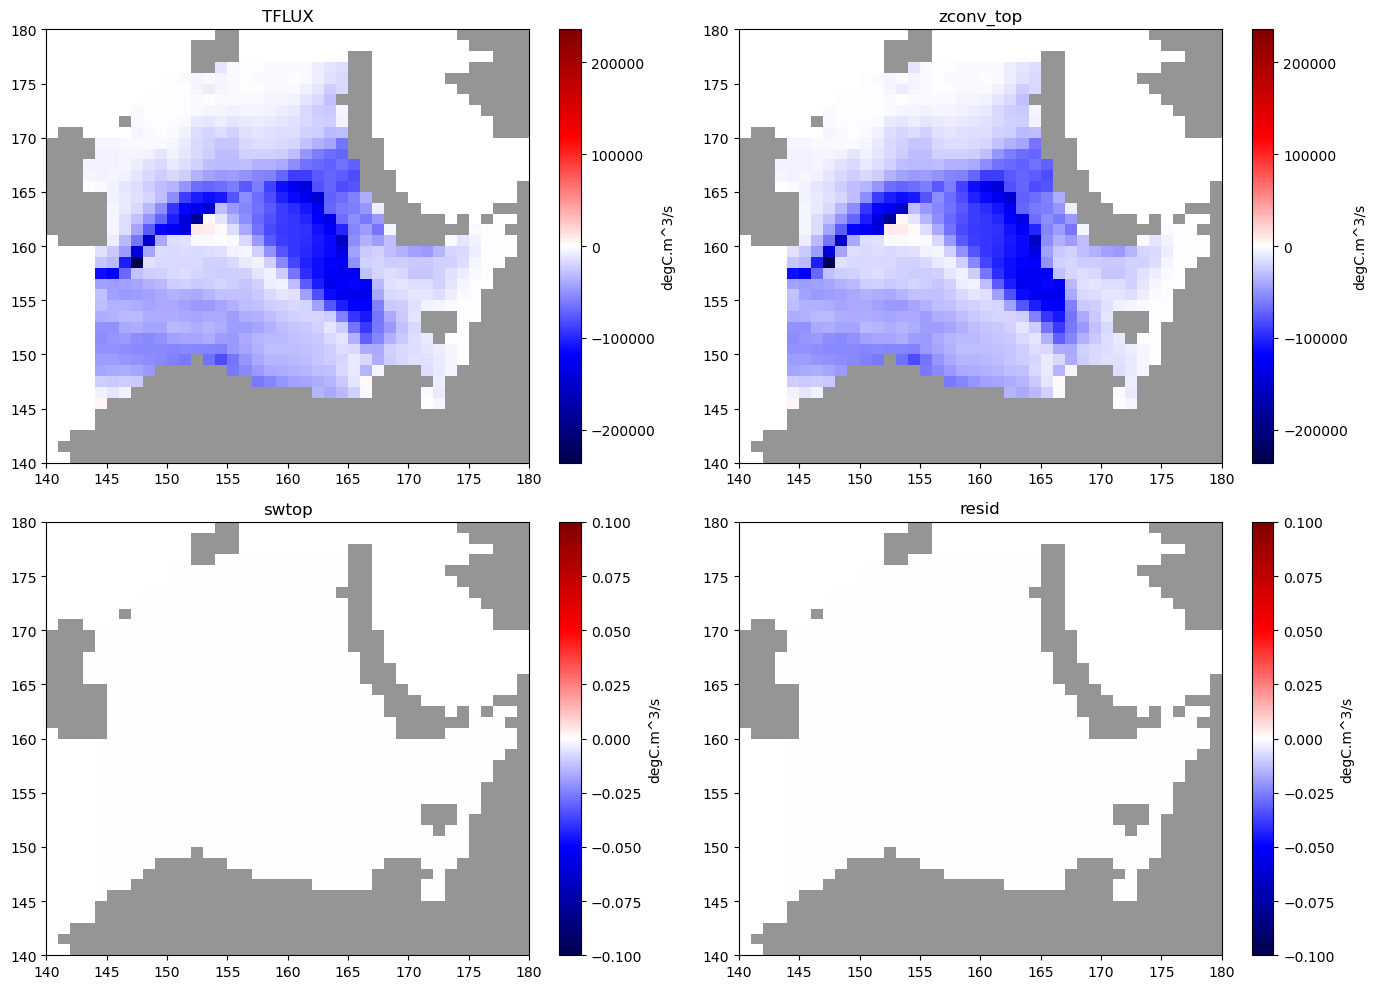

In [19]:
fig = plt.figure(figsize=(14, 10))
klev = 0

plot_terms = {
    "TFLUX": termsT3D["TFLUX"][klev] * mymsk,
    "zconv_top": termsT3D["zconv_top"][klev] * mymsk,
    "swtop": termsT3D["swtop"][klev] * mymsk,
    "resid": ((termsT3D["zconv_top"][klev] + termsT3D["swtop"][klev]) * mymsk) - (termsT3D["TFLUX"][klev] * mymsk),
} 

for ii, (name, fld) in enumerate(plot_terms.items()):
    ax = plt.subplot(2, 2, ii + 1)

    fld_plot = get_aste_tracer(fld, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label="degC.m^3/s")
    ax.set_title(name)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)

plt.tight_layout()

In [20]:
# try to load the terms from the ice budget to do the same thing

In [21]:
from plotting_helpersmini import plot_any_BS

In [22]:
budgI_zconv = -(SItflux+TFLUX-TRELAX)

budgI_zconv=budgI_zconv-SIabflux+SIacflux+SIeprflx+SIaaflux
budgI_zconv.shape

(450, 90)

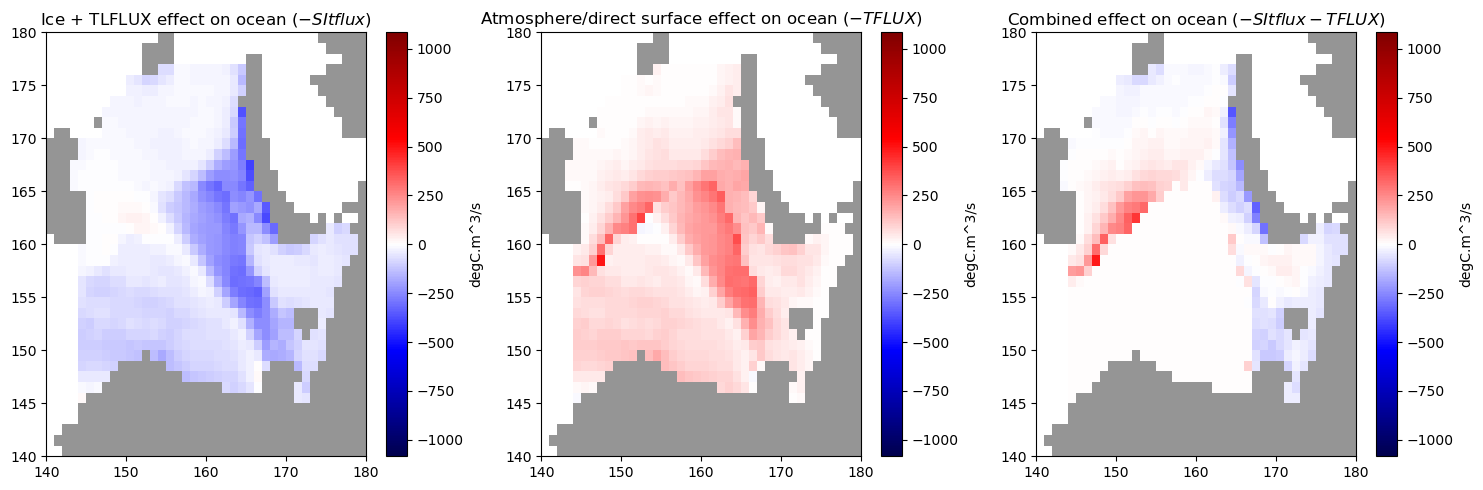

In [23]:
unit = "degC.m^3/s"

# --------------------------------------------------
# Ocean-centered sign convention:
# positive = warming ocean
# negative = cooling ocean
# --------------------------------------------------

# Heat going into ice removes heat from ocean
term_ice_on_ocean = -SItflux

# If your ocean budget uses -TFLUX, keep that convention here
term_atm_on_ocean = -TFLUX

# Combined effect of ice + direct surface flux on ocean
term_total_on_ocean = term_ice_on_ocean + term_atm_on_ocean

fields = [
    term_ice_on_ocean,
    term_atm_on_ocean,
    term_total_on_ocean
]

titles = [
    r'Ice + TLFLUX effect on ocean ($-SItflux$)',
    r'Atmosphere/direct surface effect on ocean ($-TFLUX$)',
    r'Combined effect on ocean ($-SItflux - TFLUX$)'
]

# common color scale
allmax = np.nanmax([np.nanmax(np.abs(f)) for f in fields])
vmin = -allmax
vmax = allmax

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fld, title in zip(axes, fields, titles):
    fld_plot = get_aste_tracer(fld, nfx, nfy)[0] * get_aste_tracer(mymsk, nfx, nfy)[0]

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    ax.set_title(title)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)
    plt.colorbar(cb, ax=ax, label=unit)

plt.tight_layout()
plt.show()

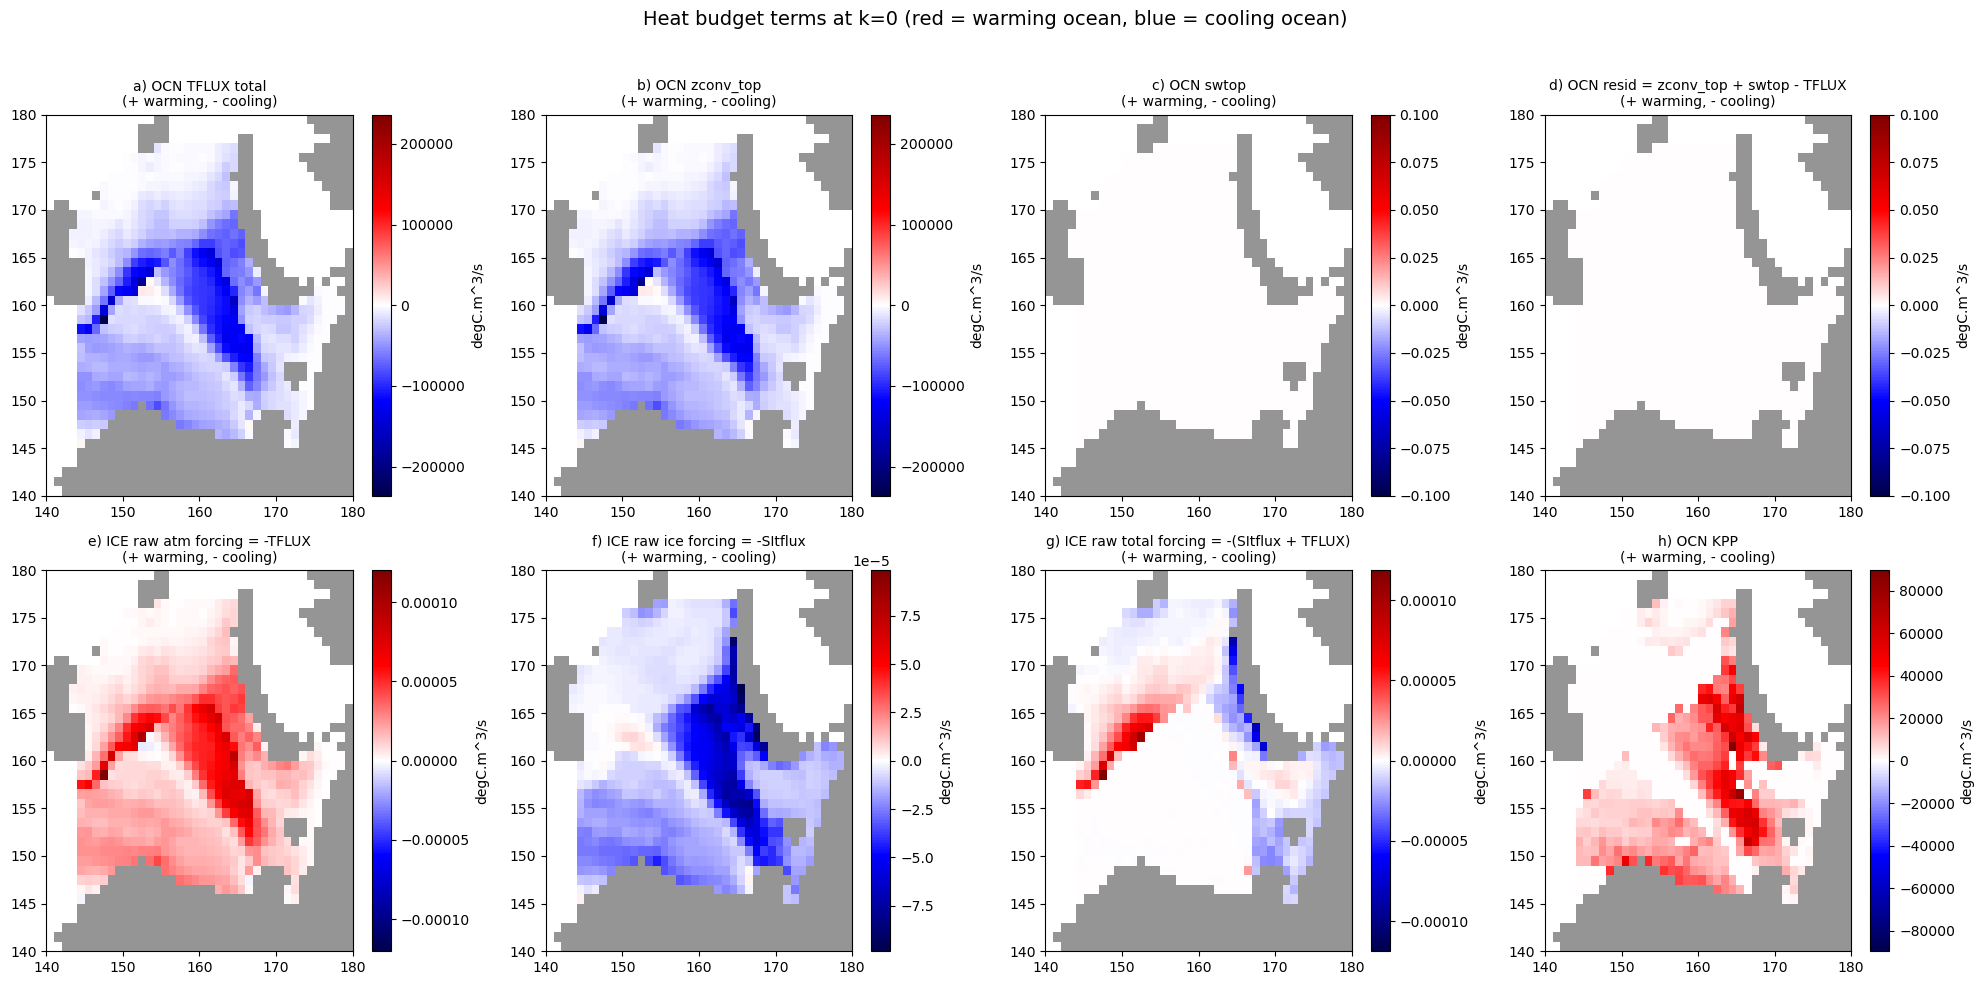

In [24]:
fig = plt.figure(figsize=(20, 10))
klev = 0
unit = "degC.m^3/s"

# --------------------------------------------------
# heat terms from budget decomposition
# sign convention: + warms ocean, - cools ocean
# --------------------------------------------------
TFLUX_term     = termsT3D["TFLUX"][klev] * mymsk
zconv_top_term = termsT3D["zconv_top"][klev] * mymsk
swtop_term     = termsT3D["swtop"][klev] * mymsk
resid_term     = (termsT3D["zconv_top"][klev] + termsT3D["swtop"][klev] - termsT3D["TFLUX"][klev]) * mymsk

# --------------------------------------------------
# raw surface forcing terms
# ocean-centered sign convention:
# + = warming ocean
# - = cooling ocean
# --------------------------------------------------
atm_term_raw   = (-TFLUX / myparms["rcp"]) * mymsk
ice_term_raw   = (-SItflux / myparms["rcp"]) * mymsk
total_term_raw = (-(SItflux + TFLUX) / myparms["rcp"]) * mymsk

# --------------------------------------------------
# KPP term from original 3D heat terms
# adjust key if needed
# --------------------------------------------------
kpp_term = termsT3Dorig["KPP"][klev] * mymsk
# alternatives, if your key is different:
# kpp_term = termsT3Dorig["KPPg_TH"][klev] * mymsk
# kpp_term = termsT3Dorig["kpp"][klev] * mymsk

plot_terms = {
    "a) OCN TFLUX total\n(+ warming, - cooling)": TFLUX_term,
    "b) OCN zconv_top\n(+ warming, - cooling)": zconv_top_term,
    "c) OCN swtop\n(+ warming, - cooling)": swtop_term,
    "d) OCN resid = zconv_top + swtop - TFLUX\n(+ warming, - cooling)": resid_term,
    "e) ICE raw atm forcing = -TFLUX\n(+ warming, - cooling)": atm_term_raw,
    "f) ICE raw ice forcing = -SItflux\n(+ warming, - cooling)": ice_term_raw,
    "g) ICE raw total forcing = -(SItflux + TFLUX)\n(+ warming, - cooling)": total_term_raw,
    "h) OCN KPP\n(+ warming, - cooling)": kpp_term,
}

for ii, (name, fld) in enumerate(plot_terms.items()):
    ax = plt.subplot(2, 4, ii + 1)

    fld_plot = get_aste_tracer(fld, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap="seismic",
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap="Greys",
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label=unit)
    ax.set_title(name, fontsize=10)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)

plt.suptitle("Heat budget terms at k=0 (red = warming ocean, blue = cooling ocean)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## do the same thing for salt

In [25]:
# read fluxes
# load the surface salt terms
file_name = 'budg2d_zflux_set1'
meta_budg2d_zflux_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set1["fldList"])
rec_oceSPflx = np.where(fldlist == "oceSPflx")[0][0]
rec_SFLUX    = np.where(fldlist == "SFLUX")[0][0]
oceSPflx, its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_oceSPflx)
SFLUX,    its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_SFLUX)
oceSPflx = oceSPflx.reshape(ny, nx)
SFLUX    = SFLUX.reshape(ny, nx)

# read relax and salt mass
file_name = "budg2d_zflux_set2"
meta_budg2d_zflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set2["fldList"])
print(fldlist)
varnames = np.array(["oceSflux","WSLTMASS","SRELAX"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    if len(irec[0]) > 0:
        recs = np.append(recs, irec[0][0])
oceSflux,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
WSLTMASS,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
oceSflux = oceSflux.reshape(ny,nx)
WSLTMASS = WSLTMASS.reshape(ny,nx)

['WTHMASS' 'WSLTMASS' 'oceSflux' 'oceQnet' 'SIatmQnt' 'SIaaflux'
 'SIsnPrcp' 'SIacSubl']


In [26]:
layers_path

'/scratch3/atnguyen/aste_90x150x60/run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/'

In [27]:


file_name = "budg3d_kpptend_set1"
meta_budg3d_kpptend_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_kpptend_set1["fldList"])

rec_oceSPtnd = np.where(fldlist == "oceSPtnd")[0][0]

oceSPtnd, its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_oceSPtnd)
oceSPtnd = oceSPtnd.reshape(nz, ny, nx)

RAC3 = np.tile(RAC[np.newaxis, :, :], (nz, 1, 1))

# 3D redistributed salt surface term
sptop = mk3D_mod(oceSPflx, oceSPtnd) - np.cumsum(oceSPtnd, axis=0)
sptop = sptop * RAC3        # g/s

# 2D top boundary term
zconv_top_salt = (SFLUX + oceSPflx) * RAC   # g/s

def surface_contrib_JS(zconv_top_salt, sptop, rho, fill_last=0.0):
    """
    zconv_top_salt : (ny, nx)     top boundary salt term in g/s
    sptop          : (nz, ny, nx) redistributed salt flux profile in g/s
    returns:
      JsurfS       : (nz, ny, nx) in PSU.m^3/s
    """
    nz_, ny_, nx_ = sptop.shape
    eS = zconv_top_salt.reshape(1, ny_, nx_)
    J = np.empty_like(sptop, dtype=float)

    J[0] = (eS[0] - sptop[1]) / rho
    J[1:nz_] = -(sptop[1:nz_] - sptop[0:nz_-1]) / rho
    J[-1] = fill_last

    return J

# original full surface salt contribution
Fs_surf = surface_contrib_JS(
    zconv_top_salt,
    sptop,
    myparms['rhoconst']
)

# split into two terms
Fs_zconv_top = surface_contrib_JS(
    zconv_top_salt,
    np.zeros((nz, ny, nx)),
    myparms['rhoconst']
)

Fs_sptop = surface_contrib_JS(
    np.zeros((ny, nx)),
    sptop,
    myparms['rhoconst']
)

# mapping return
termsS3D = {}
termsS3D["surf"] = Fs_surf
termsS3D["zconv_top"] = Fs_zconv_top
termsS3D["sptop"] = Fs_sptop


Text(0.5, 1.0, 'vertical salt flux (sptop) contribution k=0')

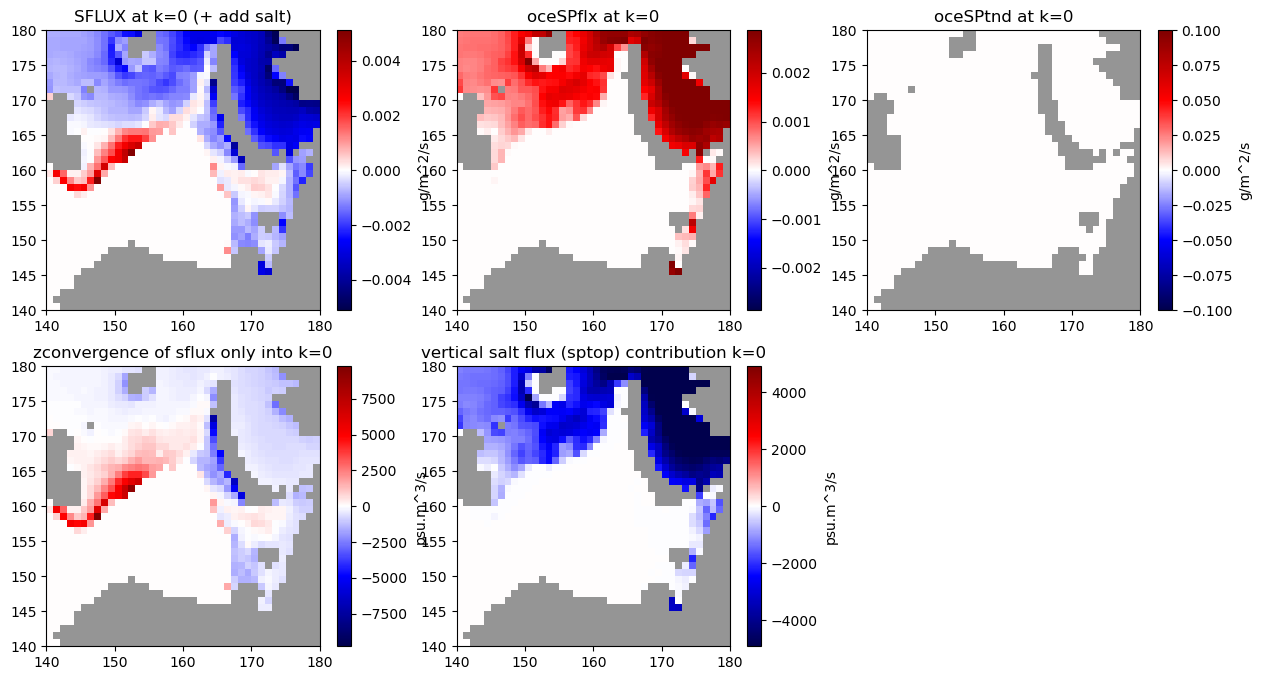

In [28]:
# make the same few plots for the salt contributions

# plot each of the terms here and the original flux

fig = plt.figure(figsize = (15,8))

ax = plt.subplot(231)
vlev = np.nanmax(np.abs(SFLUX * mymsk))
cb = ax.pcolormesh(get_aste_tracer(SFLUX,nfx,nfy)[0],cmap='seismic',vmin = -vlev,vmax=vlev)
ax.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap="Greys",vmin=0,vmax=2)
ax.set_xlim(140,180)
ax.set_ylim(140,180)
plt.colorbar(cb,label="g/m^2/s")
ax.set_title("SFLUX at k=0 (+ add salt)")

ax = plt.subplot(232)
vlev = np.nanmax(np.abs(oceSPflx * mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceSPflx,nfx,nfy)[0],cmap='seismic',vmin = -vlev,vmax=vlev)
ax.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap="Greys",vmin=0,vmax=2)
ax.set_xlim(140,180)
ax.set_ylim(140,180)
plt.colorbar(cb,label="g/m^2/s")
ax.set_title("oceSPflx at k=0")

ax = plt.subplot(233)
vlev = np.nanmax(np.abs(oceSPtnd * mymsk))
cb = ax.pcolormesh(get_aste_tracer(oceSPtnd,nfx,nfy)[0],cmap='seismic',vmin = -vlev,vmax=vlev)
ax.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap="Greys",vmin=0,vmax=2)
ax.set_xlim(140,180)
ax.set_ylim(140,180)
plt.colorbar(cb,label="g/m^2/s")
ax.set_title("oceSPtnd at k=0")


ax = plt.subplot(234)
vlev = np.nanmax(np.abs(Fs_zconv_top * mymsk))
cb = ax.pcolormesh(get_aste_tracer(Fs_zconv_top,nfx,nfy)[0],cmap='seismic',vmin = -vlev,vmax=vlev)
ax.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap="Greys",vmin=0,vmax=2)
ax.set_xlim(140,180)
ax.set_ylim(140,180)
plt.colorbar(cb,label="psu.m^3/s")
ax.set_title("zconvergence of sflux only into k=0")

ax = plt.subplot(235)
vlev = np.nanmax(np.abs(Fs_sptop * mymsk))
cb = ax.pcolormesh(get_aste_tracer(Fs_sptop,nfx,nfy)[0],cmap='seismic',vmin = -vlev,vmax=vlev)
ax.pcolormesh(get_aste_tracer(landmsk,nfx,nfy)[0],cmap="Greys",vmin=0,vmax=2)
ax.set_xlim(140,180)
ax.set_ylim(140,180)
plt.colorbar(cb,label="psu.m^3/s")
ax.set_title("vertical salt flux (sptop) contribution k=0")

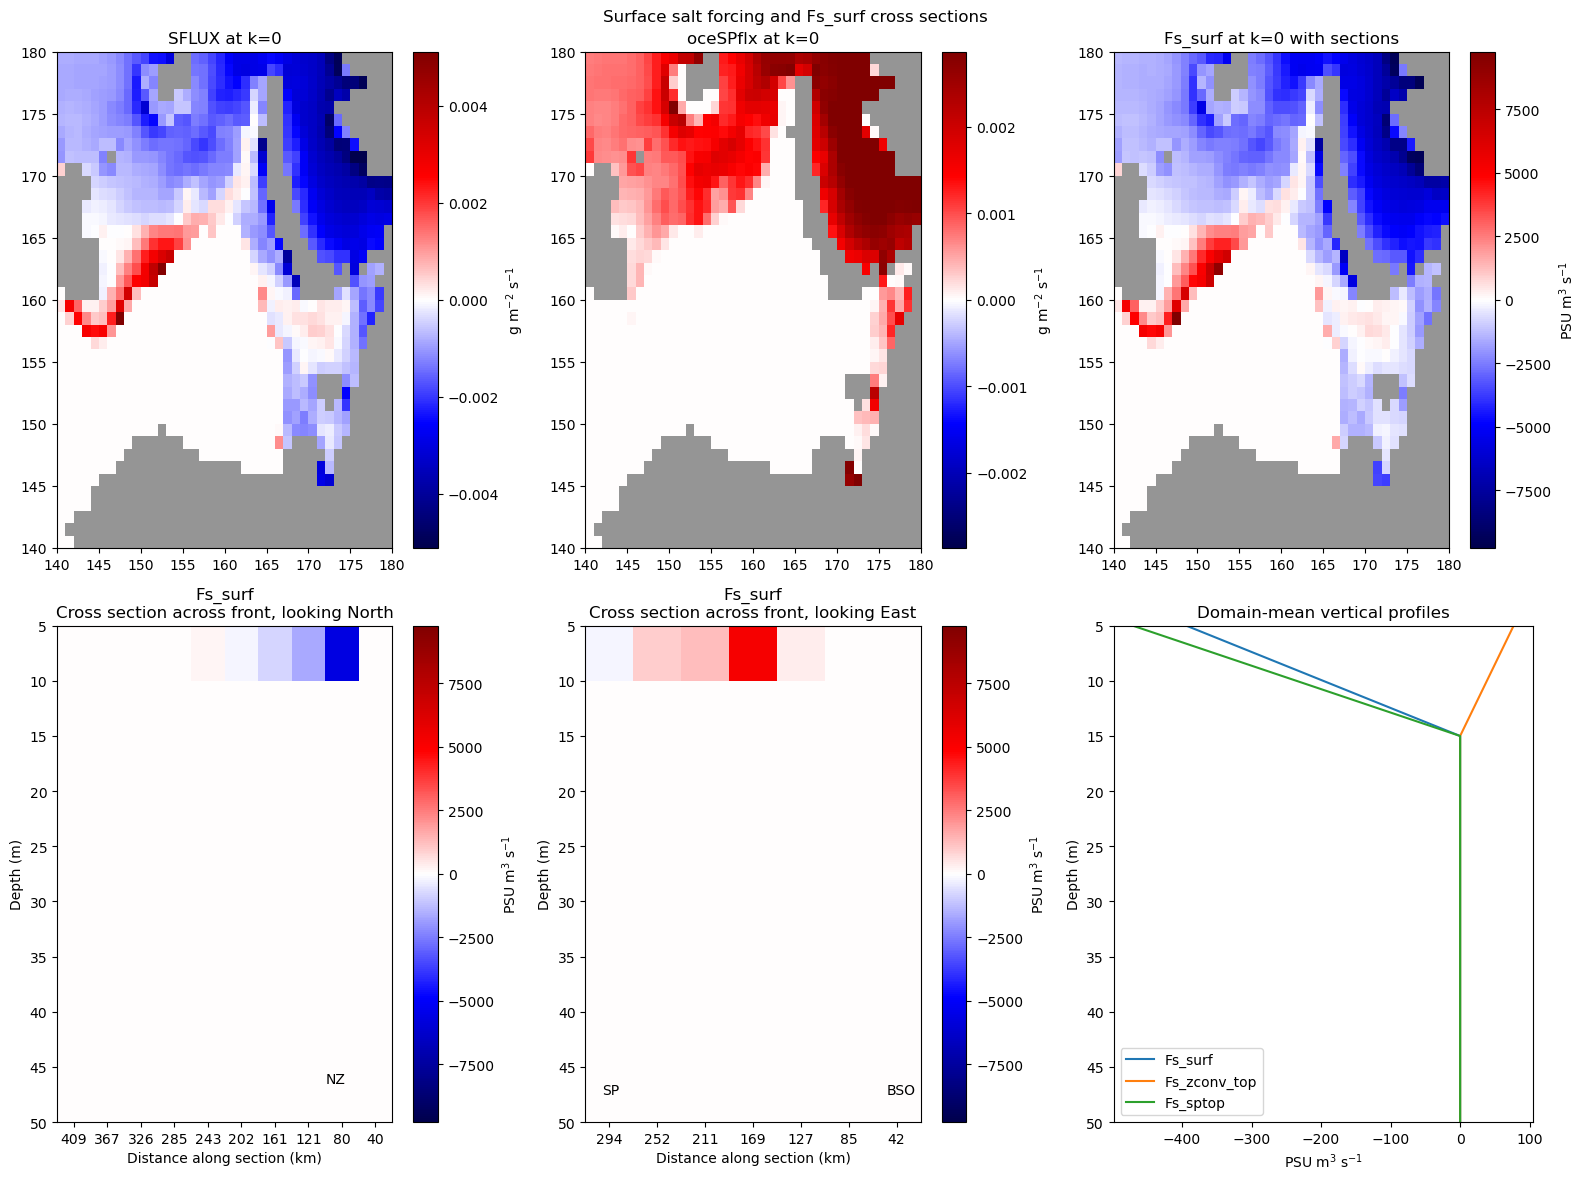

In [29]:
# --------------------------------------------------
# map + cross sections of Fs_surf
# --------------------------------------------------

fs_cmap = "seismic"
fs_vlev = np.nanmax(np.abs(Fs_surf * mymsk3d))
fs_norm = TwoSlopeNorm(vmin=-fs_vlev, vcenter=0.0, vmax=fs_vlev)

fig = plt.figure(figsize=(16, 12))

# ==================================================
# TOP ROW: surface maps
# ==================================================

ax = plt.subplot(231)
vlev = np.nanmax(np.abs(SFLUX * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(SFLUX, nfx, nfy)[0],
    cmap="seismic",
    vmin=-vlev,
    vmax=vlev,
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2,
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="g m$^{-2}$ s$^{-1}$")
ax.set_title("SFLUX at k=0")

ax = plt.subplot(232)
vlev = np.nanmax(np.abs(oceSPflx * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(oceSPflx, nfx, nfy)[0],
    cmap="seismic",
    vmin=-vlev,
    vmax=vlev,
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2,
)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="g m$^{-2}$ s$^{-1}$")
ax.set_title("oceSPflx at k=0")

ax = plt.subplot(233)
vlev = np.nanmax(np.abs(Fs_surf[0] * mymsk))
cb = ax.pcolormesh(
    get_aste_tracer(Fs_surf[0], nfx, nfy)[0],
    cmap="seismic",
    vmin=-vlev,
    vmax=vlev,
)
ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap="Greys",
    vmin=0,
    vmax=2,
)

# draw sections
ax.plot(y_section,  x_section,  color="k",    linewidth=2)
ax.plot(y_section2, x_section2, color="lime", linewidth=2)

ax.set_xlim(140, 180)
ax.set_ylim(140, 180)
plt.colorbar(cb, label="PSU m$^3$ s$^{-1}$")
ax.set_title("Fs_surf at k=0 with sections")

# ==================================================
# BOTTOM ROW: Fs_surf cross sections
# ==================================================

sections = [
    (x_section,  y_section,  "Cross section across front, looking North", "NZ"),
    (x_section2, y_section2, "Cross section across front, looking East",  "SP"),
]

for isec, (xs, ys, row_title, corner_label) in enumerate(sections):

    ax = plt.subplot(2, 3, 4 + isec)

    # field along section
    fs_sec = Fs_surf[:, xs, ys].copy()   # (nz, npts)

    # land mask
    land_hfc = mygrid["hFacC"][:, xs, ys]
    land_sec = np.full_like(land_hfc, np.nan, dtype=float)
    land_sec[land_hfc == 0] = 1

    # depth (cell centers)
    z = np.cumsum(mygrid["DRF"].squeeze())
    z1 = np.array([0])
    z1 = np.append(z1, z)
    z = (z1[1:] + z1[:-1]) / 2

    # distance along section
    yc_sec = mygrid["DYG"][xs, ys]
    dist_km = np.cumsum(yc_sec) / 1000.0
    dist_km = np.round(dist_km)

    sec_idx = np.arange(len(yc_sec))

    pcm = ax.pcolormesh(
        sec_idx,
        z,
        fs_sec,
        shading="auto",
        cmap=fs_cmap,
        norm=fs_norm,
    )

    # gray land
    ax.pcolormesh(
        sec_idx,
        z,
        land_sec,
        cmap="Greys",
        vmin=0,
        vmax=2,
        shading="auto",
    )

    tick_step = max(1, len(sec_idx) // 8)
    tick_idx = sec_idx[::tick_step]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels(dist_km.astype(int)[::tick_step])

    # annotations
    if isec == 0:
        ax.text(0.8, 0.1, corner_label, transform=ax.transAxes, va="top")
    else:
        ax.text(0.05, 0.05, corner_label, transform=ax.transAxes, va="bottom", ha="left")
        ax.text(0.9, 0.05, "BSO", transform=ax.transAxes, va="bottom", ha="left")

    ax.invert_yaxis()
    ax.invert_xaxis()
    ax.set_ylim(50, 5)

    ax.set_title(f"Fs_surf\n{row_title}")
    ax.set_xlabel("Distance along section (km)")
    ax.set_ylabel("Depth (m)")
    plt.colorbar(pcm, ax=ax, label="PSU m$^3$ s$^{-1}$")

# ==================================================
# last panel: vertical profiles
# ==================================================

ax = plt.subplot(236)

fs_surf_prof  = np.nanmean(Fs_surf      * mymsk3d, axis=(1, 2))
fs_zconv_prof = np.nanmean(Fs_zconv_top * mymsk3d, axis=(1, 2))
fs_sptop_prof = np.nanmean(Fs_sptop     * mymsk3d, axis=(1, 2))

z = np.cumsum(mygrid["DRF"].squeeze())
z1 = np.array([0])
z1 = np.append(z1, z)
z = (z1[1:] + z1[:-1]) / 2

ax.plot(fs_surf_prof,  z, label="Fs_surf")
ax.plot(fs_zconv_prof, z, label="Fs_zconv_top")
ax.plot(fs_sptop_prof, z, label="Fs_sptop")
ax.invert_yaxis()
ax.set_ylim(50, 5)
ax.set_xlabel("PSU m$^3$ s$^{-1}$")
ax.set_ylabel("Depth (m)")
ax.set_title("Domain-mean vertical profiles")
ax.legend()

plt.suptitle("Surface salt forcing and Fs_surf cross sections")
plt.tight_layout()
plt.show()

In [31]:
layers_path

'/scratch3/atnguyen/aste_90x150x60/run_c68v_heffmosm3x_layers_lessmem1_viscAHp5em2_it0000_pk0000000001/'

In [80]:
termsS3D.keys()

dict_keys(['surf', 'zconv_top', 'sptop'])

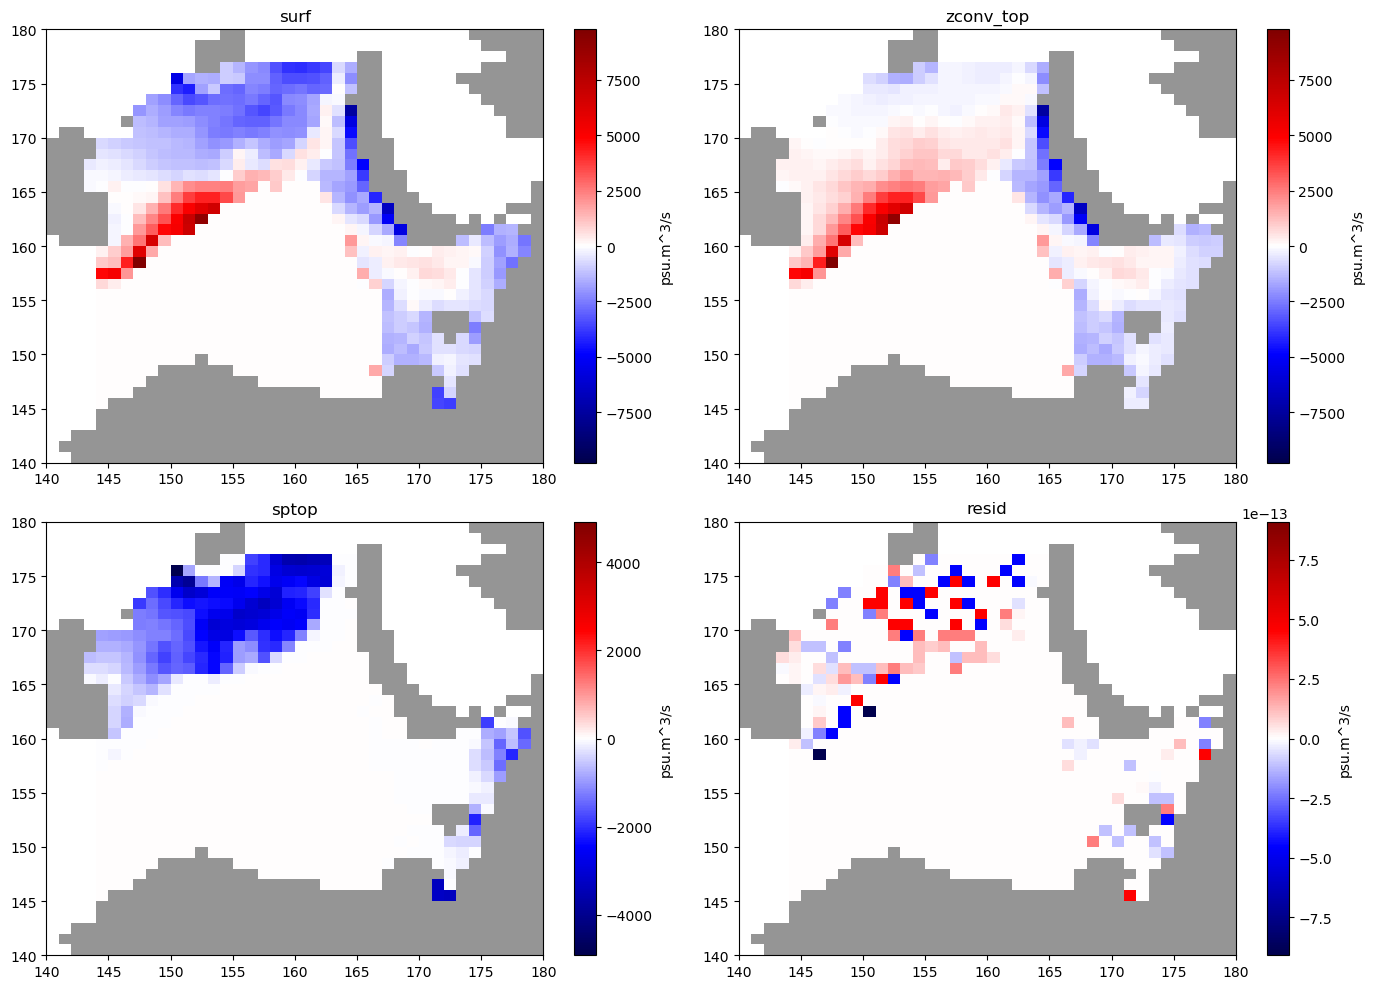

In [81]:
fig = plt.figure(figsize=(14, 10))
klev = 0

plot_terms = {
    "surf": termsS3D["surf"][klev] * mymsk,
    "zconv_top": termsS3D["zconv_top"][klev] * mymsk,
    "sptop": termsS3D["sptop"][klev] * mymsk,
    "resid": ((termsS3D["zconv_top"][klev] + termsS3D["sptop"][klev]) * mymsk) - (termsS3D["surf"][klev] * mymsk),
} 

for ii, (name, fld) in enumerate(plot_terms.items()):
    ax = plt.subplot(2, 2, ii + 1)

    fld_plot = get_aste_tracer(fld, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label="psu.m^3/s")
    ax.set_title(name)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)

plt.tight_layout()

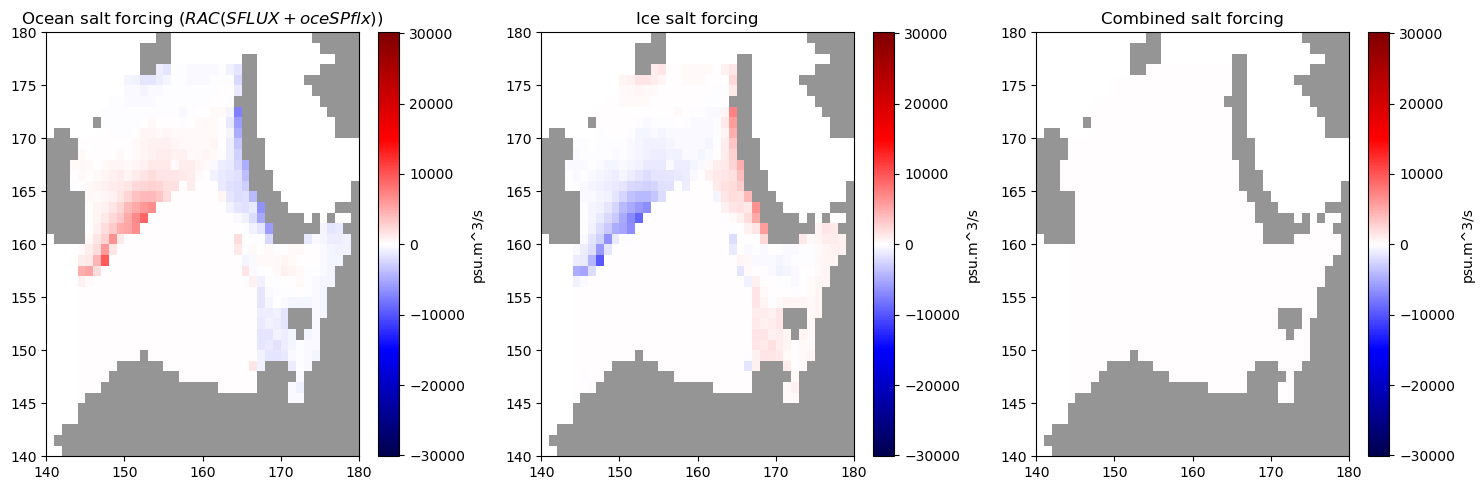

In [82]:
# make the same plot of the breakdown of the ice budget

unit = "psu.m^3/s"

# -----------------------------
# raw salt terms
# -----------------------------
ocean_salt_forcing = RAC * (SFLUX + oceSPflx)

if myparms['useNLFS'] == 0:
    ocean_salt_forcing = ocean_salt_forcing - RAC * myparms['rhoconst'] * WSLTMASS

ice_salt_forcing = RAC * (- (SFLUX + oceSPflx))

if myparms['useRFWF'] == 0 or myparms['useNLFS'] == 0:
    ice_salt_forcing = -RAC * oceSflux

total_salt_forcing = ocean_salt_forcing + ice_salt_forcing

# -----------------------------
# fields to plot
# -----------------------------
fields = [
    ocean_salt_forcing / myparms['rhoconst'],
    ice_salt_forcing / myparms['rhoconst'],
    total_salt_forcing / myparms['rhoconst']
]

titles = [
    r'Ocean salt forcing ($RAC(SFLUX + oceSPflx)$)',
    r'Ice salt forcing',
    r'Combined salt forcing'
]

# common color scale
allmax = np.nanmax([np.nanmax(np.abs(f)) for f in fields])
vmin = -allmax
vmax = allmax

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fld, title in zip(axes, fields, titles):
    fld_plot = get_aste_tracer(fld, nfx, nfy)[0] * get_aste_tracer(mymsk, nfx, nfy)[0]

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    ax.set_title(title)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)
    plt.colorbar(cb, ax=ax, label=unit)

plt.tight_layout()
plt.show()

## I think we can also split these up further, see previous notebook for the full ice and heat budget

In [26]:
# maybe we can load the ice budget here

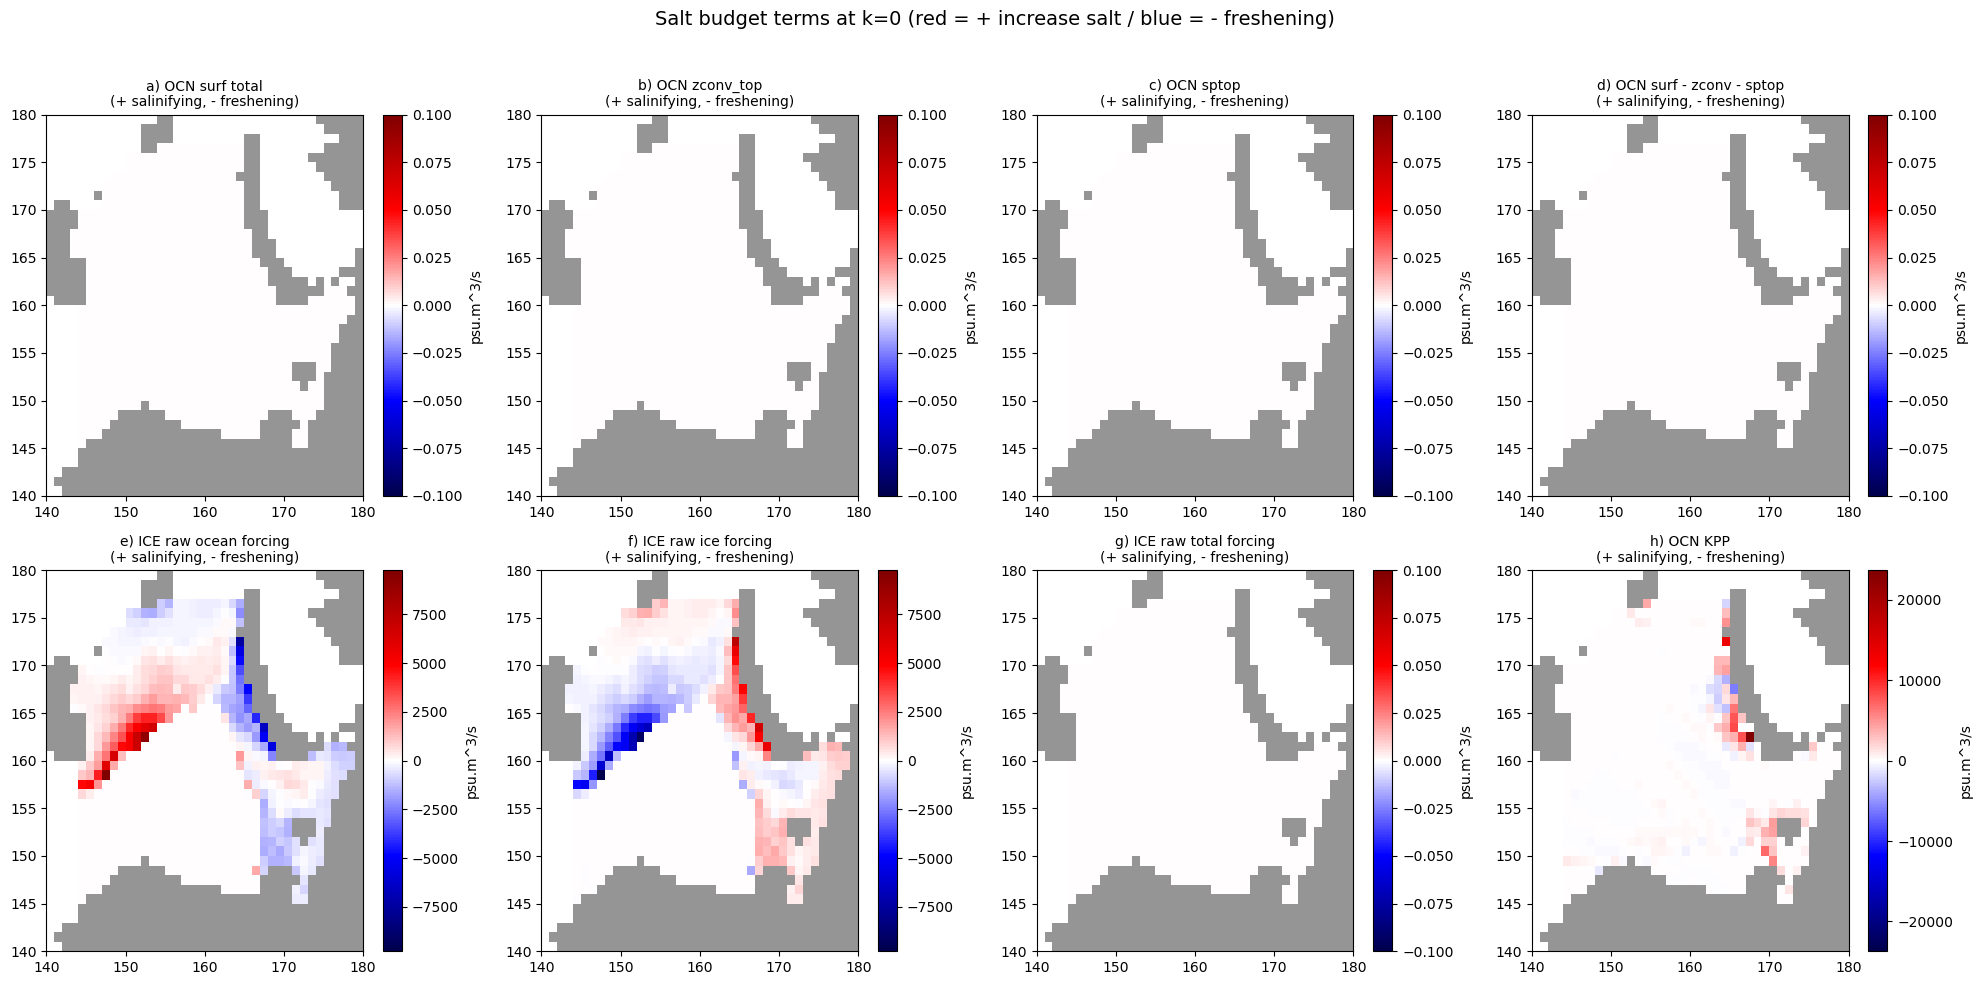

In [27]:
fig = plt.figure(figsize=(20, 10))
klev = 2
unit = "psu.m^3/s"

surf_term      = termsS3D["surf"][klev] * mymsk
zconv_top_term = termsS3D["zconv_top"][klev] * mymsk
sptop_term     = termsS3D["sptop"][klev] * mymsk
resid_term     = (termsS3D["zconv_top"][klev] + termsS3D["sptop"][klev] - termsS3D["surf"][klev]) * mymsk

ocean_salt_forcing = RAC * (SFLUX + oceSPflx)
if myparms['useNLFS'] == 0:
    ocean_salt_forcing = ocean_salt_forcing - RAC * myparms['rhoconst'] * WSLTMASS

ice_salt_forcing = RAC * (-(SFLUX + oceSPflx))
if myparms['useRFWF'] == 0 or myparms['useNLFS'] == 0:
    ice_salt_forcing = -RAC * oceSflux

ocean_term_raw = (ocean_salt_forcing / myparms['rhoconst']) * mymsk
ice_term_raw   = (ice_salt_forcing / myparms['rhoconst']) * mymsk
total_term_raw = ((ocean_salt_forcing + ice_salt_forcing) / myparms['rhoconst']) * mymsk

kpp_term = termsS3Dorig["KPP"][klev] * mymsk

plot_terms = {
    "a) OCN surf total\n(+ salinifying, - freshening)": surf_term,
    "b) OCN zconv_top\n(+ salinifying, - freshening)": zconv_top_term,
    "c) OCN sptop\n(+ salinifying, - freshening)": sptop_term,
    "d) OCN surf - zconv - sptop\n(+ salinifying, - freshening)": resid_term,
    "e) ICE raw ocean forcing\n(+ salinifying, - freshening)": ocean_term_raw,
    "f) ICE raw ice forcing\n(+ salinifying, - freshening)": ice_term_raw,
    "g) ICE raw total forcing\n(+ salinifying, - freshening)": total_term_raw,
    "h) OCN KPP\n(+ salinifying, - freshening)": kpp_term,
}

for ii, (name, fld) in enumerate(plot_terms.items()):
    ax = plt.subplot(2, 4, ii + 1)

    fld_plot = get_aste_tracer(fld, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label=unit)
    ax.set_title(name, fontsize=10)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)

plt.suptitle("Salt budget terms at k=0 (red = + increase salt / blue = - freshening)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

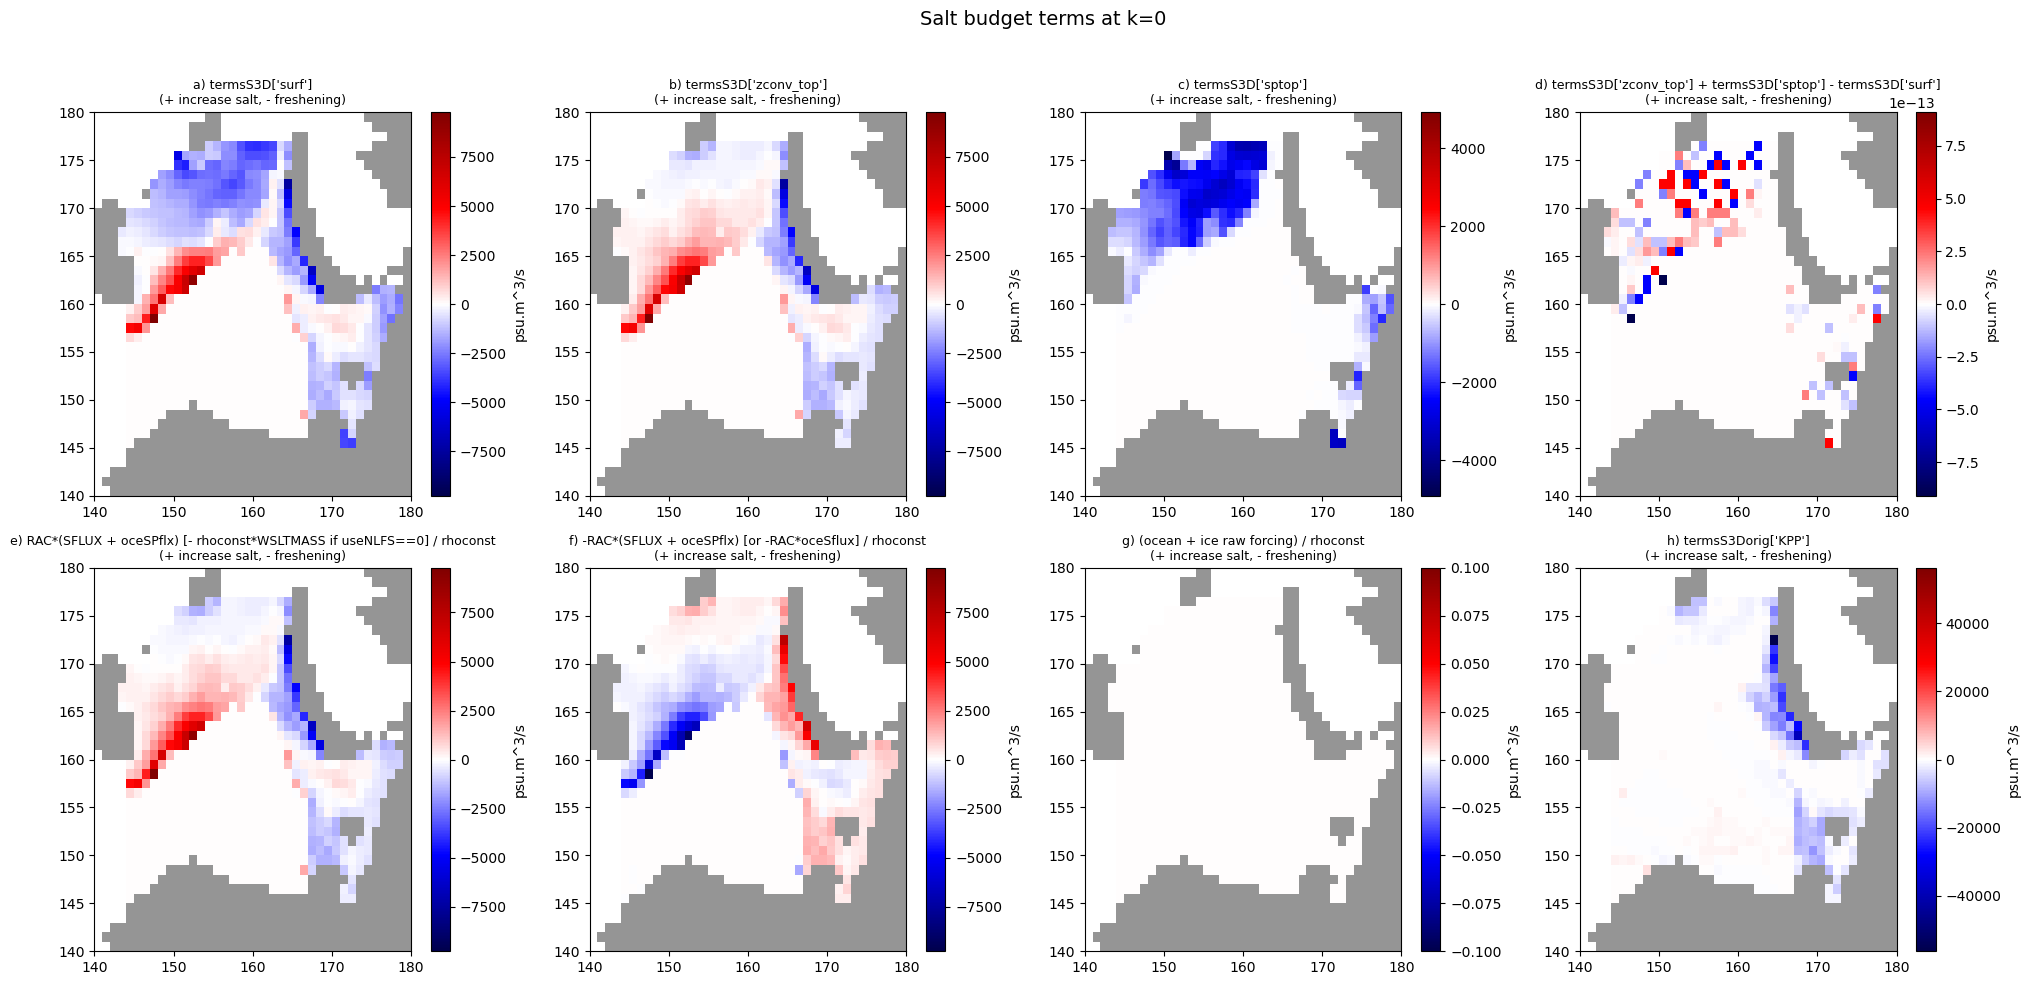

In [28]:
fig = plt.figure(figsize=(20, 10))
klev = 0
unit = "psu.m^3/s"

surf_term      = termsS3D["surf"][klev] * mymsk
zconv_top_term = termsS3D["zconv_top"][klev] * mymsk
sptop_term     = termsS3D["sptop"][klev] * mymsk
resid_term     = (termsS3D["zconv_top"][klev] + termsS3D["sptop"][klev] - termsS3D["surf"][klev]) * mymsk

ocean_salt_forcing = RAC * (SFLUX + oceSPflx)
if myparms['useNLFS'] == 0:
    ocean_salt_forcing = ocean_salt_forcing - RAC * myparms['rhoconst'] * WSLTMASS

ice_salt_forcing = RAC * (-(SFLUX + oceSPflx))
if myparms['useRFWF'] == 0 or myparms['useNLFS'] == 0:
    ice_salt_forcing = -RAC * oceSflux

ocean_term_raw = (ocean_salt_forcing / myparms['rhoconst']) * mymsk
ice_term_raw   = (ice_salt_forcing / myparms['rhoconst']) * mymsk
total_term_raw = ((ocean_salt_forcing + ice_salt_forcing) / myparms['rhoconst']) * mymsk

kpp_term = termsS3Dorig["KPP"][klev] * mymsk

plot_terms = {
    r"a) termsS3D['surf']": surf_term,
    r"b) termsS3D['zconv_top']": zconv_top_term,
    r"c) termsS3D['sptop']": sptop_term,
    r"d) termsS3D['zconv_top'] + termsS3D['sptop'] - termsS3D['surf']": resid_term,
    r"e) RAC*(SFLUX + oceSPflx) [- rhoconst*WSLTMASS if useNLFS==0] / rhoconst": ocean_term_raw,
    r"f) -RAC*(SFLUX + oceSPflx) [or -RAC*oceSflux] / rhoconst": ice_term_raw,
    r"g) (ocean + ice raw forcing) / rhoconst": total_term_raw,
    r"h) termsS3Dorig['KPP']": kpp_term,
}

for ii, (name, fld) in enumerate(plot_terms.items()):
    ax = plt.subplot(2, 4, ii + 1)

    fld_plot = get_aste_tracer(fld, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label=unit)
    ax.set_title(name + "\n(+ increase salt, - freshening)", fontsize=9)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)

plt.suptitle("Salt budget terms at k=0", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

In [ ]:
# c above is the one from salt flux rejected into the ocean during freezing

In [117]:
# we need to make a raw plot of SFLUX and KPP (as this is a vertical convergence term
# read kpp tend and from 3d zflux
file_name = "budg3d_kpptend_set1"
meta_budg3d_kpptend_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_kpptend_set1["fldList"])
print(fldlist)
varnames = np.array(["oceSPtnd","KPPg_SLT","KPPg_TH"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    if len(irec[0]) > 0:
        recs = np.append(recs, irec[0][0])
oceSPtnd,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
KPPg_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
KPPg_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[2])
oceSPtnd = oceSPtnd.reshape(nz,ny,nx)
KPPg_SLT = KPPg_SLT.reshape(nz,ny,nx)
KPPg_TH = KPPg_TH.reshape(nz,ny,nx)

['KPPg_TH' 'KPPg_SLT' 'TOTTTEND' 'TOTSTEND' 'oceSPtnd' 'TOTETEND'
 'WVELMASS' 'oceQsw3D']


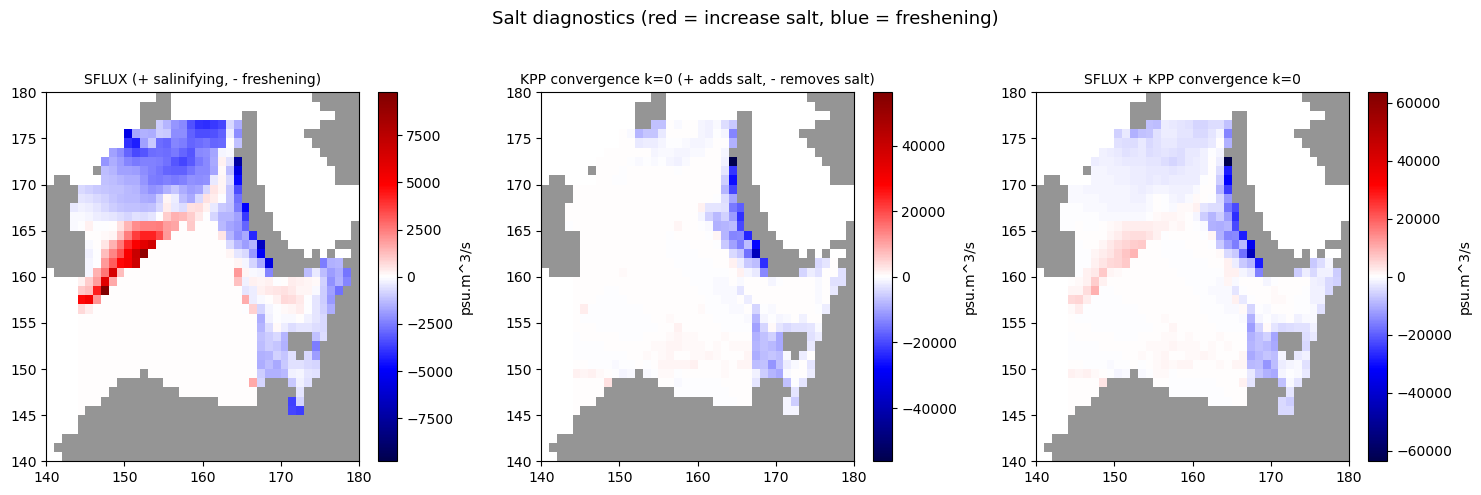

In [31]:
fig = plt.figure(figsize=(15, 5))
unit = "psu.m^3/s"

# --------------------------------------------------
# surface salt forcing
# + = increases salt
# - = freshens
# --------------------------------------------------
fld_sflux = SFLUX * RAC / myparms['rhoconst']

# --------------------------------------------------
# KPP vertical convergence
# trWtopKPP is the vertical KPP salt flux at the top face
# tmpkpp is the convergence contribution in each layer
# + = adds salt to the layer
# - = removes salt from the layer
# --------------------------------------------------
trWtopKPP = -KPPg_SLT                      # psu.m^3/s

tmpkpp = np.full((nz, ny, nx), np.nan)
tmpkpp[:-1, :, :] = trWtopKPP[:-1, :, :] - trWtopKPP[1:, :, :]
tmpkpp[-1, :, :] = 0.0

klev = 0
fld_kpp_conv = tmpkpp[klev]

# combined diagnostic view
fld_sum = fld_sflux + fld_kpp_conv

fields = [fld_sflux, fld_kpp_conv, fld_sum]
titles = [
    "SFLUX (+ salinifying, - freshening)",
    f"KPP convergence k={klev} (+ adds salt, - removes salt)",
    f"SFLUX + KPP convergence k={klev}"
]

for ii, (fld, title) in enumerate(zip(fields, titles)):
    ax = plt.subplot(1, 3, ii + 1)

    fld_plot = get_aste_tracer(fld * mymsk, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld_plot))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label=unit)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(140, 180)
    ax.set_ylim(140, 180)

plt.suptitle("Salt diagnostics (red = increase salt, blue = freshening)", fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [32]:
SFLUX

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 0.00000000e+00, -2.16840434e-19,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  1.08420217e-19, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

(140.0, 180.0)

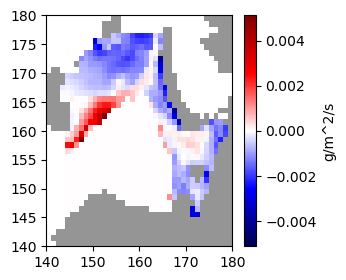

In [37]:
fig = plt.figure(figsize = (3,3))
ax = plt.subplot(111)
fld = SFLUX

fld_plot = get_aste_tracer(fld * mymsk, nfx, nfy)[0]

vmax = np.nanmax(np.abs(fld_plot))
vmin = -vmax

cb = ax.pcolormesh(
    fld_plot,
    cmap='seismic',
    vmin=vmin,
    vmax=vmax
)

ax.pcolormesh(
    get_aste_tracer(landmsk, nfx, nfy)[0],
    cmap='Greys',
    vmin=0,
    vmax=2
)

plt.colorbar(cb, ax=ax, label="g/m^2/s")
# ax.set_title(title, fontsize=10)
ax.set_xlim(140, 180)
ax.set_ylim(140, 180)


## Can we compare SIheff or SIarea change at these two timesteps to try and look at growth?

In [48]:
# we need to also create the theta and salt bins for this area
tsstr = np.array(["0000000004","0000000005"])
t2 = int(tsstr[1]) # for the offline version

In [49]:
file_name = "state_2d_set1"
meta_state_2d_set1 = parsemeta(dirstate + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_state_2d_set1["fldList"])
print(fldlist)

varnames = np.array(["SIarea", "SIheff", "sIceLoad"])

recs = np.array([], dtype=int)
for var in varnames:
    irec = np.where(fldlist == var)[0][0]
    recs = np.append(recs, irec)

t1 = int(tsstr[0])
t2 = int(tsstr[1])

# load all three fields at t1
SIarea_t1, its, meta = rdmds(os.path.join(dirstate, file_name), t1, returnmeta=True, rec=recs[0])
SIheff_t1, its, meta = rdmds(os.path.join(dirstate, file_name), t1, returnmeta=True, rec=recs[1])
sIceLoad_t1, its, meta = rdmds(os.path.join(dirstate, file_name), t1, returnmeta=True, rec=recs[2])

SIarea_t1   = SIarea_t1.reshape(ny, nx)
SIheff_t1   = SIheff_t1.reshape(ny, nx)
sIceLoad_t1 = sIceLoad_t1.reshape(ny, nx)

# load all three fields at t2
SIarea_t2, its, meta = rdmds(os.path.join(dirstate, file_name), t2, returnmeta=True, rec=recs[0])
SIheff_t2, its, meta = rdmds(os.path.join(dirstate, file_name), t2, returnmeta=True, rec=recs[1])
sIceLoad_t2, its, meta = rdmds(os.path.join(dirstate, file_name), t2, returnmeta=True, rec=recs[2])

SIarea_t2   = SIarea_t2.reshape(ny, nx)
SIheff_t2   = SIheff_t2.reshape(ny, nx)
sIceLoad_t2 = sIceLoad_t2.reshape(ny, nx)

# differences
dSIarea   = SIarea_t2 - SIarea_t1
dSIheff   = SIheff_t2 - SIheff_t1
dsIceLoad = sIceLoad_t2 - sIceLoad_t1

['ETAN' 'SIarea' 'SIheff' 'SIhsnow' 'DETADT2' 'PHIBOT' 'sIceLoad'
 'MXLDEPTH' 'SIatmQnt' 'SIatmFW' 'oceQnet' 'oceFWflx' 'oceTAUX' 'oceTAUY'
 'ADVxHEFF' 'ADVyHEFF' 'ADVxSNOW' 'ADVySNOW' 'SIuice' 'SIvice' 'ETANSQ'
 'oceSPDep']


In [50]:
def plot_aste_2d(fld, title="", cbar_label="", xlim=(140,180), ylim=(140,180), mask=mymsk):
    fig = plt.figure(figsize=(3,3))tt
    ax = plt.subplot(111)

    fld_plot = get_aste_tracer(fld * mask, nfx, nfy)[0]

    vmax = np.nanmax(np.abs(fld_plot))
    vmin = -vmax

    cb = ax.pcolormesh(
        fld_plot,
        cmap='seismic',
        vmin=vmin,
        vmax=vmax
    )

    ax.pcolormesh(
        get_aste_tracer(landmsk, nfx, nfy)[0],
        cmap='Greys',
        vmin=0,
        vmax=2
    )

    plt.colorbar(cb, ax=ax, label=cbar_label)
    ax.set_title(title, fontsize=10)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    plt.show()

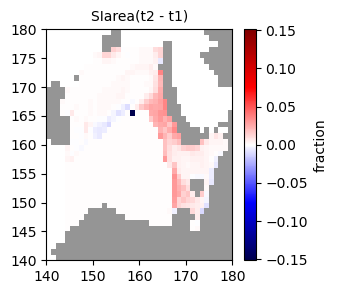

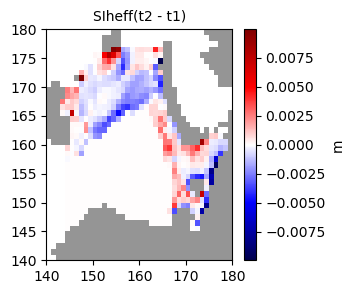

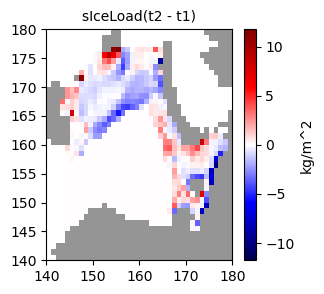

In [51]:
plot_aste_2d(dSIarea,   title="SIarea(t2 - t1)",   cbar_label="fraction")
plot_aste_2d(dSIheff,   title="SIheff(t2 - t1)",   cbar_label="m")
plot_aste_2d(dsIceLoad, title="sIceLoad(t2 - t1)", cbar_label="kg/m^2")

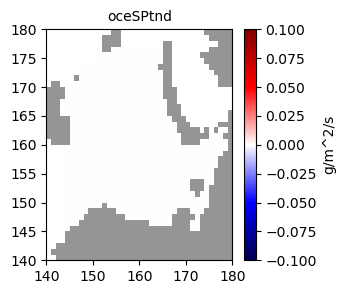

In [55]:
plot_aste_2d(oceSPtnd[1],   title="oceSPtnd",   cbar_label="g/m^2/s")

## what did we learn here

- the area near novaya zemlya is not actually forming new ice, ice is decreasing here between time steps
- we don't have the exf fields so we can't see empmr, but we can look at the same time in the big aste and see there is freshwater lost at the ice edge
- ice load is increasing in the area where we see a lot of vertical mixing, not where kpp is

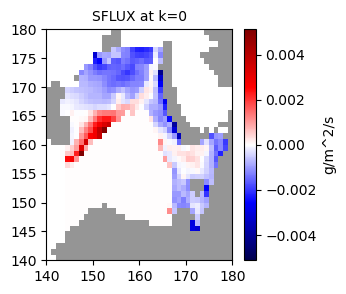

In [88]:
plot_aste_2d(SFLUX,   title="SFLUX at k=0",   cbar_label="g/m^2/s")

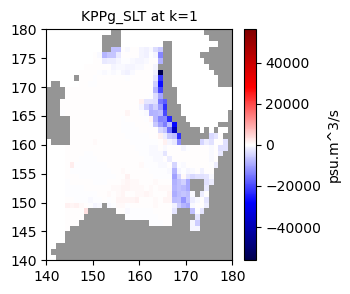

In [89]:
plot_aste_2d(KPPg_SLT[1],   title="KPPg_SLT at k=1",   cbar_label="psu.m^3/s")

In [113]:
file_name = "budg3d_zflux_set2"
meta_budg3d_zflux_set2 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_zflux_set2["fldList"])
varnames = np.array(["DFrE_SLT","DFrI_SLT"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
DFrE_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
DFrI_SLT,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
DFrE_SLT = DFrE_SLT.reshape(nz,ny,nx)
DFrI_SLT = DFrI_SLT.reshape(nz,ny,nx)


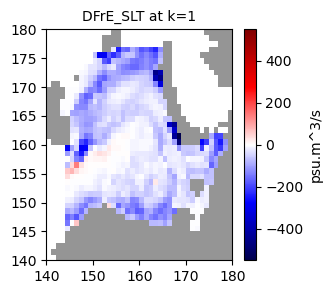

In [95]:
plot_aste_2d(DFrE_SLT[1],   title="DFrE_SLT at k=1",   cbar_label="psu.m^3/s")

What do the above two plots mean? sflux is removing salt from the ocean at the coast of Novaya Zemlya. nonlocal turbulent mixing is pushing salt downward out of the surface layer. the surface is being freshened, while turbulent mixing is exporting salt from the surface layer into deeper water. Salt is also being transported downward at the interface k=1, but more salt enters from the top (0), so the vertical convergence of salt into this layer is positive.

In [96]:
def plot_aste_2d_triptych(
    fields,
    titles=None,
    cbar_labels=None,
    xlim=(140, 180),
    ylim=(140, 180),
    mask=None,
    landmask=landmsk,
    nfx=nfx,
    nfy=nfy,
    cmaps=None,
    figsize=(10, 3),
):
    """
    Plot three ASTE fields side by side.

    Parameters
    ----------
    fields : list of 3 arrays
        Each field should be 2D on the native ASTE grid.
    titles : list of 3 str
    cbar_labels : list of 3 str
    xlim, ylim : tuple
    mask : 2D array or None
        Applied to all fields if provided.
    landmask : 2D array
    cmaps : list of 3 colormap names or None
    """
    if len(fields) != 3:
        raise ValueError("fields must contain exactly 3 arrays")
    
    if titles is None:
        titles = ["", "", ""]
    if cbar_labels is None:
        cbar_labels = ["", "", ""]
    if cmaps is None:
        cmaps = ["seismic", "seismic", "seismic"]

    fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

    land_plot = get_aste_tracer(landmask, nfx, nfy)[0]

    for ax, fld, title, cbar_label, cmap in zip(axs, fields, titles, cbar_labels, cmaps):
        fld_use = fld.copy()
        if mask is not None:
            fld_use = fld_use * mask

        fld_plot = get_aste_tracer(fld_use, nfx, nfy)[0]

        vmax = np.nanmax(np.abs(fld_plot))
        vmin = -vmax

        pcm = ax.pcolormesh(
            fld_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto"
        )

        ax.pcolormesh(
            land_plot,
            cmap="Greys",
            vmin=0,
            vmax=2,
            shading="auto"
        )

        fig.colorbar(pcm, ax=ax, label=cbar_label)
        ax.set_title(title, fontsize=10)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

    plt.show()

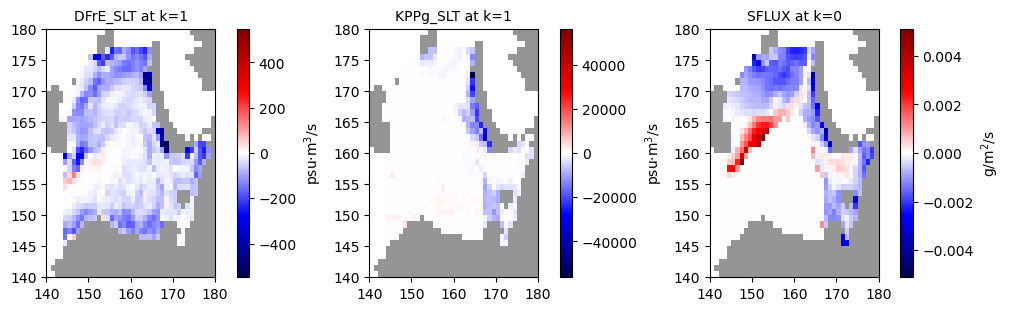

In [99]:
plot_aste_2d_triptych(
    fields=[DFrE_SLT[1], KPPg_SLT[1], SFLUX],
    titles=["DFrE_SLT at k=1", "KPPg_SLT at k=1", "SFLUX at k=0"],
    cbar_labels=["psu·m$^3$/s", "psu·m$^3$/s", "g/m$^2$/s"],
    mask=mymsk
)

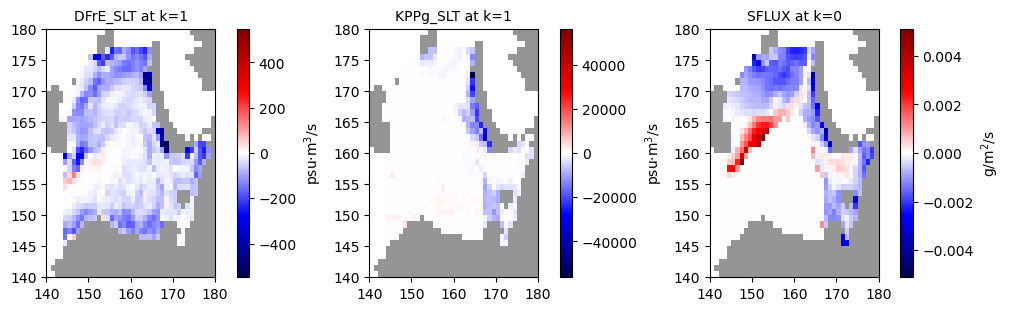

In [100]:
plot_aste_2d_triptych(
    fields=[DFrE_SLT[1]-DFrE_SLT[0], KPPg_SLT[1], SFLUX],
    titles=["DFrE_SLT at k=1", "KPPg_SLT at k=1", "SFLUX at k=0"],
    cbar_labels=["psu·m$^3$/s", "psu·m$^3$/s", "g/m$^2$/s"],
    mask=mymsk
)

In [101]:
# put vertical fluxes into a "downward positive into the cell top" style proxy
trWtop_DF  = -DFrE_SLT          # explicit vertical diffusive flux at cell tops
trWtop_KPP = -KPPg_SLT          # KPP flux rewritten with same top-flux sign style

# top-layer convergence proxies
DF_conv_k0  = SFLUX - trWtop_DF[0]
KPP_conv_k0 = SFLUX - trWtop_KPP[0]   # only if you want to compare boundary vs KPP export
SFC_conv_k0 = SFLUX

In [102]:
# fluxes at the top of each model cell, rewritten so positive means downward into the cell
trWtop_DF  = -DFrE_SLT
trWtop_KPP = -KPPg_SLT

# convergence into top layer (k=0)
# top boundary = SFLUX
# bottom boundary = flux through bottom of layer 0, represented by top of layer 1
DF_conv_k0  = SFLUX - trWtop_DF[1]
KPP_conv_k0 =      0 - trWtop_KPP[1]   # KPP contribution to layer-0 tendency
SFC_conv_k0 = SFLUX

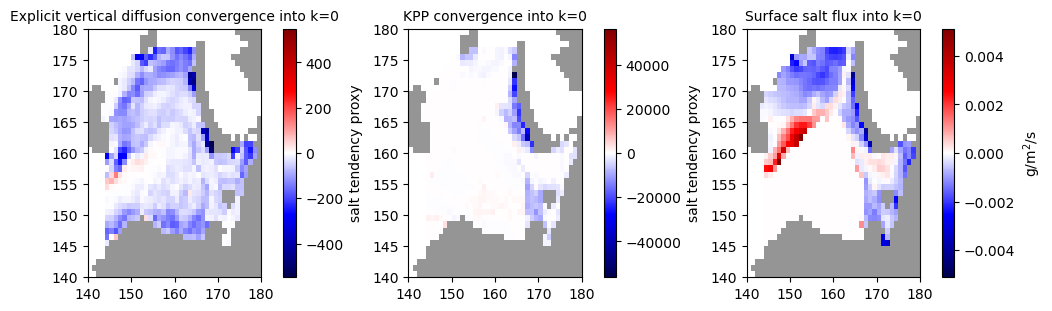

In [103]:
plot_aste_2d_triptych(
    fields=[DF_conv_k0, KPP_conv_k0, SFC_conv_k0],
    titles=[
        "Explicit vertical diffusion convergence into k=0",
        "KPP convergence into k=0",
        "Surface salt flux into k=0"
    ],
    cbar_labels=[
        "salt tendency proxy",
        "salt tendency proxy",
        "g/m$^2$/s"
    ],
    mask=mymsk
)

In [108]:
def plot_aste_2d_fourpanel(
    fields,
    titles=None,
    cbar_labels=None,
    xlim=(140, 180),
    ylim=(140, 180),
    mask=None,
    landmask=landmsk,
    nfx=nfx,
    nfy=nfy,
    cmaps=None,
    figsize=(14, 3),
):
    if len(fields) != 4:
        raise ValueError("fields must contain exactly 4 arrays")

    if titles is None:
        titles = ["", "", "", ""]
    if cbar_labels is None:
        cbar_labels = ["", "", "", ""]
    if cmaps is None:
        cmaps = ["seismic", "seismic", "seismic", "seismic"]

    fig, axs = plt.subplots(1, 4, figsize=figsize, constrained_layout=True)
    land_plot = get_aste_tracer(landmask, nfx, nfy)[0]

    for ax, fld, title, cbar_label, cmap in zip(axs, fields, titles, cbar_labels, cmaps):
        fld_use = fld.copy()
        if mask is not None:
            fld_use = fld_use * mask

        fld_plot = get_aste_tracer(fld_use, nfx, nfy)[0]
        vmax = np.nanmax(np.abs(fld_plot))/3
        vmin = -vmax if np.isfinite(vmax) else None

        pcm = ax.pcolormesh(
            fld_plot,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            shading="auto"
        )

        ax.pcolormesh(
            land_plot,
            cmap="Greys",
            vmin=0,
            vmax=2,
            shading="auto"
        )

        fig.colorbar(pcm, ax=ax, label=cbar_label)
        ax.set_title(title, fontsize=10)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)

    plt.show()

In [109]:
trWtop_DFrE = -DFrE_SLT
trWtop_DFrI = -DFrI_SLT
trWtop_KPP  = -KPPg_SLT

DFre_conv_k0 = SFLUX - trWtop_DFrE[1]
DFri_conv_k0 = SFLUX - trWtop_DFrI[1]
KPP_conv_k0  = -trWtop_KPP[1]
SFC_conv_k0  = SFLUX

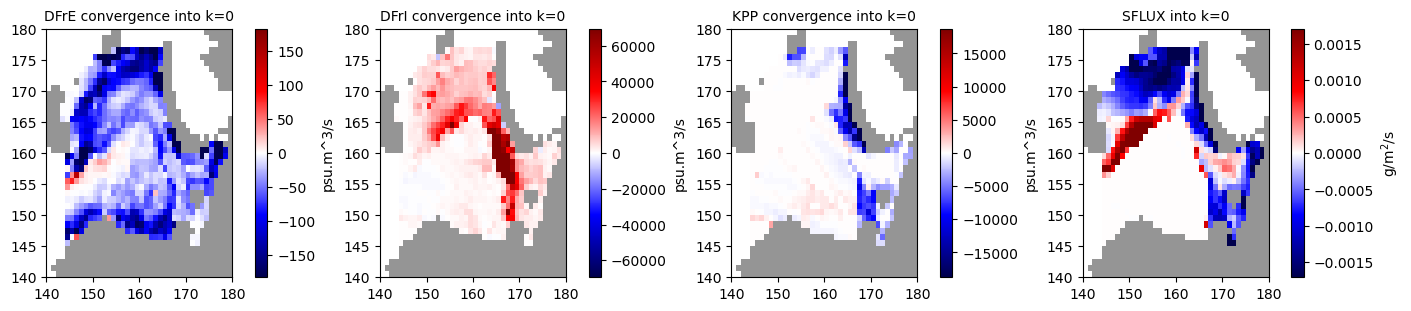

In [110]:
plot_aste_2d_fourpanel(
    fields=[DFre_conv_k0, DFri_conv_k0, KPP_conv_k0, SFC_conv_k0],
    titles=[
        "DFrE convergence into k=0",
        "DFrI convergence into k=0",
        "KPP convergence into k=0",
        "SFLUX into k=0"
    ],
    cbar_labels=[
        "psu.m^3/s",
        "psu.m^3/s",
        "psu.m^3/s",
        "g/m$^2$/s"
    ],
    mask=mymsk
)

So KPP is counterbalancing the implicit vertical diffusion. And the advection term (see slides).

## do the same thing with the theta terms.

we need TFLUX, DFrE, DFrI, KPPg_TH

In [114]:
# now 3d zfluxes
file_name = "budg3d_zflux_set1"
meta_budg3d_zflux_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_zflux_set1["fldList"])
varnames = np.array(["DFrE_TH","DFrI_TH"])
recs = np.array([])
for var in varnames:
    irec = np.where(fldlist == var)
    recs = np.append(recs, irec[0][0])
DFrE_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[0])
DFrI_TH,its,meta = rdmds(os.path.join(dirdiags, file_name),t2,returnmeta=True,rec=recs[1])
DFrE_TH = DFrE_TH.reshape(nz,ny,nx)
DFrI_TH = DFrI_TH.reshape(nz,ny,nx)

In [119]:
# Put vertical fluxes into a consistent "contribution to top-layer tendency" form
# negative sign because these are fluxes through the bottom of the top layer

DFre_convT_k0 = -(-DFrE_TH[1])   # equivalently: DFrE_TH[1]
DFri_convT_k0 = -(-DFrI_TH[1])   # equivalently: DFrI_TH[1]
KPP_convT_k0  = -(-KPPg_TH[1])   # equivalently: KPPg_TH[1]
SFC_convT_k0  = TFLUX

In [120]:
DFre_convT_k0 = DFrE_TH[1]
DFri_convT_k0 = DFrI_TH[1]
KPP_convT_k0  = KPPg_TH[1]
SFC_convT_k0  = TFLUX

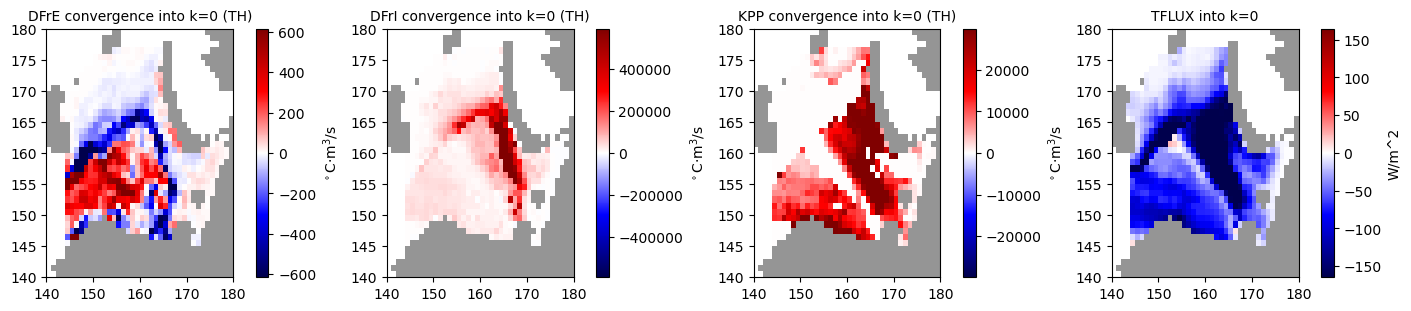

In [122]:
plot_aste_2d_fourpanel(
    fields=[DFre_convT_k0, DFri_convT_k0, KPP_convT_k0, SFC_convT_k0],
    titles=[
        "DFrE convergence into k=0 (TH)",
        "DFrI convergence into k=0 (TH)",
        "KPP convergence into k=0 (TH)",
        "TFLUX into k=0"
    ],
    cbar_labels=[
        r"$^\circ$C·m$^3$/s",
        r"$^\circ$C·m$^3$/s",
        r"$^\circ$C·m$^3$/s",
        r"W/m^2"
    ],
    mask=mymsk
)

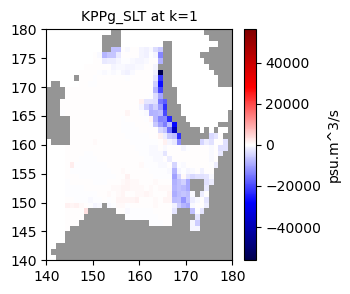

In [124]:
plot_aste_2d(KPPg_SLT[1],   title="KPPg_SLT at k=1",   cbar_label="psu.m^3/s")

In [128]:
# read fluxes
# load the surface salt terms
file_name = 'budg2d_zflux_set1'
meta_budg2d_zflux_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg2d_zflux_set1["fldList"])
rec_oceSPflx = np.where(fldlist == "oceSPflx")[0][0]
rec_SFLUX    = np.where(fldlist == "SFLUX")[0][0]
oceSPflx, its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_oceSPflx)
SFLUX,    its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_SFLUX)
oceSPflx = oceSPflx.reshape(ny, nx)
SFLUX    = SFLUX.reshape(ny, nx)

In [145]:
file_name = "budg3d_kpptend_set1"
meta_budg3d_kpptend_set1 = parsemeta(dirdiags + file_name + "." + tsstr[0] + ".meta")
fldlist = np.array(meta_budg3d_kpptend_set1["fldList"])
print(fldlist)

rec_oceSPtnd = np.where(fldlist == "oceSPtnd")[0][0]
print(rec_oceSPtnd)

oceSPtnd, its, meta = rdmds(os.path.join(dirdiags, file_name), t2, returnmeta=True, rec=rec_oceSPtnd)
oceSPtnd = oceSPtnd.reshape(nz, ny, nx)

['KPPg_TH' 'KPPg_SLT' 'TOTTTEND' 'TOTSTEND' 'oceSPtnd' 'TOTETEND'
 'WVELMASS' 'oceQsw3D']
4


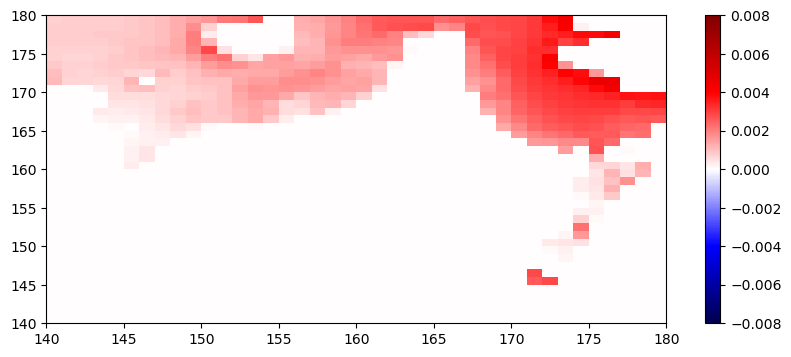

In [151]:
plt.pcolormesh(get_aste_tracer(oceSPflx,nfx,nfy)[0],cmap='seismic',vmin=-.008,vmax=.008)
plt.xlim(140,180)
plt.ylim(140,180)
plt.colorbar()

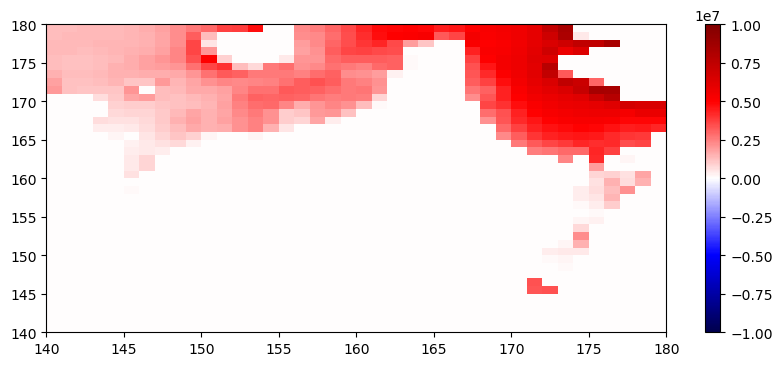

In [150]:
plt.pcolormesh(get_aste_tracer(sptop,nfx,nfy)[0],cmap='seismic',vmin=-1e7,vmax=1e7)
plt.xlim(140,180)
plt.ylim(140,180)
plt.colorbar()

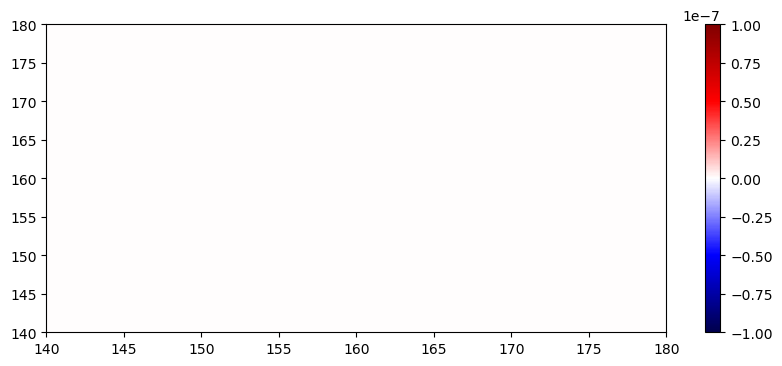

In [147]:
plt.pcolormesh(get_aste_tracer(oceSPtnd,nfx,nfy)[1],cmap='seismic',vmin=-1e-7,vmax=1e-7)
plt.xlim(140,180)
plt.ylim(140,180)
plt.colorbar()

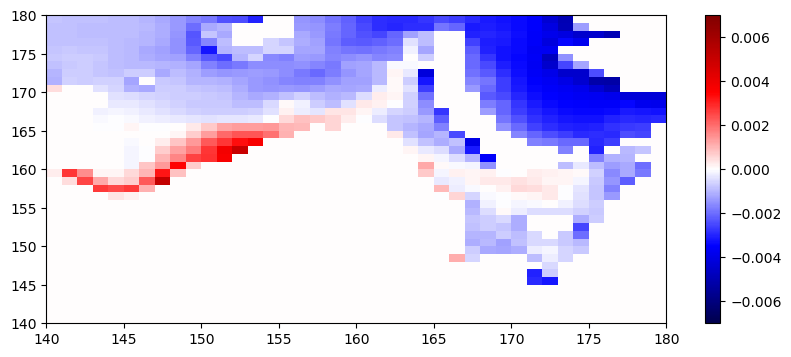

In [133]:
plt.pcolormesh(get_aste_tracer(SFLUX,nfx,nfy)[0],cmap='seismic',vmin=-.007,vmax=.007)
plt.xlim(140,180)
plt.ylim(140,180)
plt.colorbar()

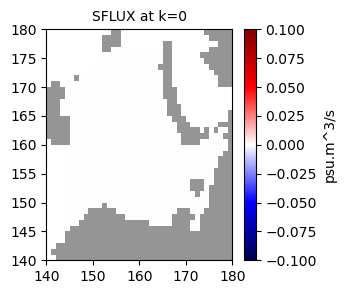

In [129]:
plot_aste_2d(SFLUX[1],   title="SFLUX at k=0",   cbar_label="psu.m^3/s")

What do we see from this. Implicit diffusion is very large and kpp is very large bringing heat into this layer (stabilizing). TFLUX is removing heat from this layer (destabilizing).

### brief summary of the physics at the edge


- implicit vertical diffusion adds salt and heat to the surface layer near NZ
- KPP removes salt from the surface layer and adds heat
- sflux removes salt from the surface layer
- tflux removes heat from the surface layer
- dfr explicit is relatively small

NZ ATTEMPT TO EXPLAIN:
Explanation of salt budget:
- sflux is surface freshening, this is consistent with ice melt (under ice) or runoff, STABILIZING
- kpp is removing salt at the surface layer, kpp is also freshening the surface (redistribution, STABILIZING)
- DFrI is bringing salt into the surface layer (compensatory, DESTABILIZING) downgradient with vertical salinity structure
- freshened at the top, further depleted by downard transport from KPP, partially replenished by implicit vertical diffusion

Explanation of heat budget:
- tflux is very neative, cooling strongly DESTABILIZING
- dfri brings heat into the surface layer, STABILIZING
- kpp brings heat into the surface layer, STABILIZING


Why are these behaving differently?
The surface is undergoing cooling and freshening under the sea ice over a warmer and saltier subsurface. Vertical mixing attempts to bring these properties upwards. KPP for the salt budget is still freshening the surface despite surface freshening from SFLUX because the vertical diffusion is so strong. DF is still quite large compared to the surface forcing for salt (which is very small). So which buoyancy effect is larger? If the cooling dominates density, then turbulance and mixing intensify to bring heat to the surface. If freshening dominates density, you still have an active surface boundary layer without deep overturning.

### Question to settle

Net buoyancy flux matters more than individual parts. We want to know what appears to bring properties of AW to the surface (appears here in heat budget). What is the thermal contribution to the buoyancy? What is the haline contribution to the buoyancy? And what are the vertical gradients of T or S?

We want to know whether this is cooling-driven overturning partly suppressed by freshening, or a stably stratified fresh surface layer with active turbulence but limited convection.